# Data Preparation EDA

Deep-dive exploration of the prepared LAND_AS dataset, including:
- Raw feature files (`reanalysis_daily.npz`, `dem.npz`)
- Assembled weekly dataset (`weekly_dataset.npz`)
- Rainfall distributions, temporal patterns, station coverage, climate variable statistics, and DEM characteristics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})

DATA_DIR = Path('../data')
FEATURE_DIR = DATA_DIR / 'features'
DATASET_PATH = DATA_DIR / 'weekly_dataset.npz'

print('Feature files:', [f.name for f in FEATURE_DIR.iterdir()])
print('Dataset file:', DATASET_PATH.exists())

Feature files: ['dem.npz', 'reanalysis_daily.npz']
Dataset file: True


---
## 1. Raw Reanalysis Features

In [2]:
reanalysis = np.load(FEATURE_DIR / 'reanalysis_daily.npz', allow_pickle=True)
print('Keys:', list(reanalysis.keys()))
for key in reanalysis.keys():
    arr = reanalysis[key]
    print(f'  {key}: shape={arr.shape}, dtype={arr.dtype}')

Keys: ['patches', 'stations', 'years', 'months', 'days', 'variables']
  patches: shape=(62535, 15, 3, 3), dtype=float32
  stations: shape=(62535,), dtype=object
  years: shape=(62535,), dtype=int32
  months: shape=(62535,), dtype=int32
  days: shape=(62535,), dtype=int32
  variables: shape=(15,), dtype=object


In [3]:
# Variable names
variables = reanalysis['variables']
print(f'Number of climate variables: {len(variables)}')
for i, v in enumerate(variables):
    print(f'  [{i}] {v}')

Number of climate variables: 15
  [0] air_2m
  [1] hgt_500
  [2] hgt_1000
  [3] omega_500
  [4] pottmp_diff_500_1000
  [5] pottmp_diff_850_1000
  [6] pr_wtr
  [7] shum_750
  [8] shum_925
  [9] zon_moist_750
  [10] zon_moist_925
  [11] merid_moist_750
  [12] merid_moist_925
  [13] wind_div_925
  [14] skin_temp


In [4]:
# Reanalysis patch spatial dimensions & sample statistics
patches = reanalysis['patches']
n_samples, n_channels, h, w = patches.shape
print(f'Reanalysis patches: {n_samples} samples x {n_channels} channels x {h}x{w} grid')
print(f'Year range: {reanalysis["years"].min()} - {reanalysis["years"].max()}')
print(f'Unique stations: {len(np.unique(reanalysis["stations"]))}')
print(f'Unique years: {len(np.unique(reanalysis["years"]))}')

Reanalysis patches: 62535 samples x 15 channels x 3x3 grid
Year range: 1980 - 2024
Unique stations: 26
Unique years: 42


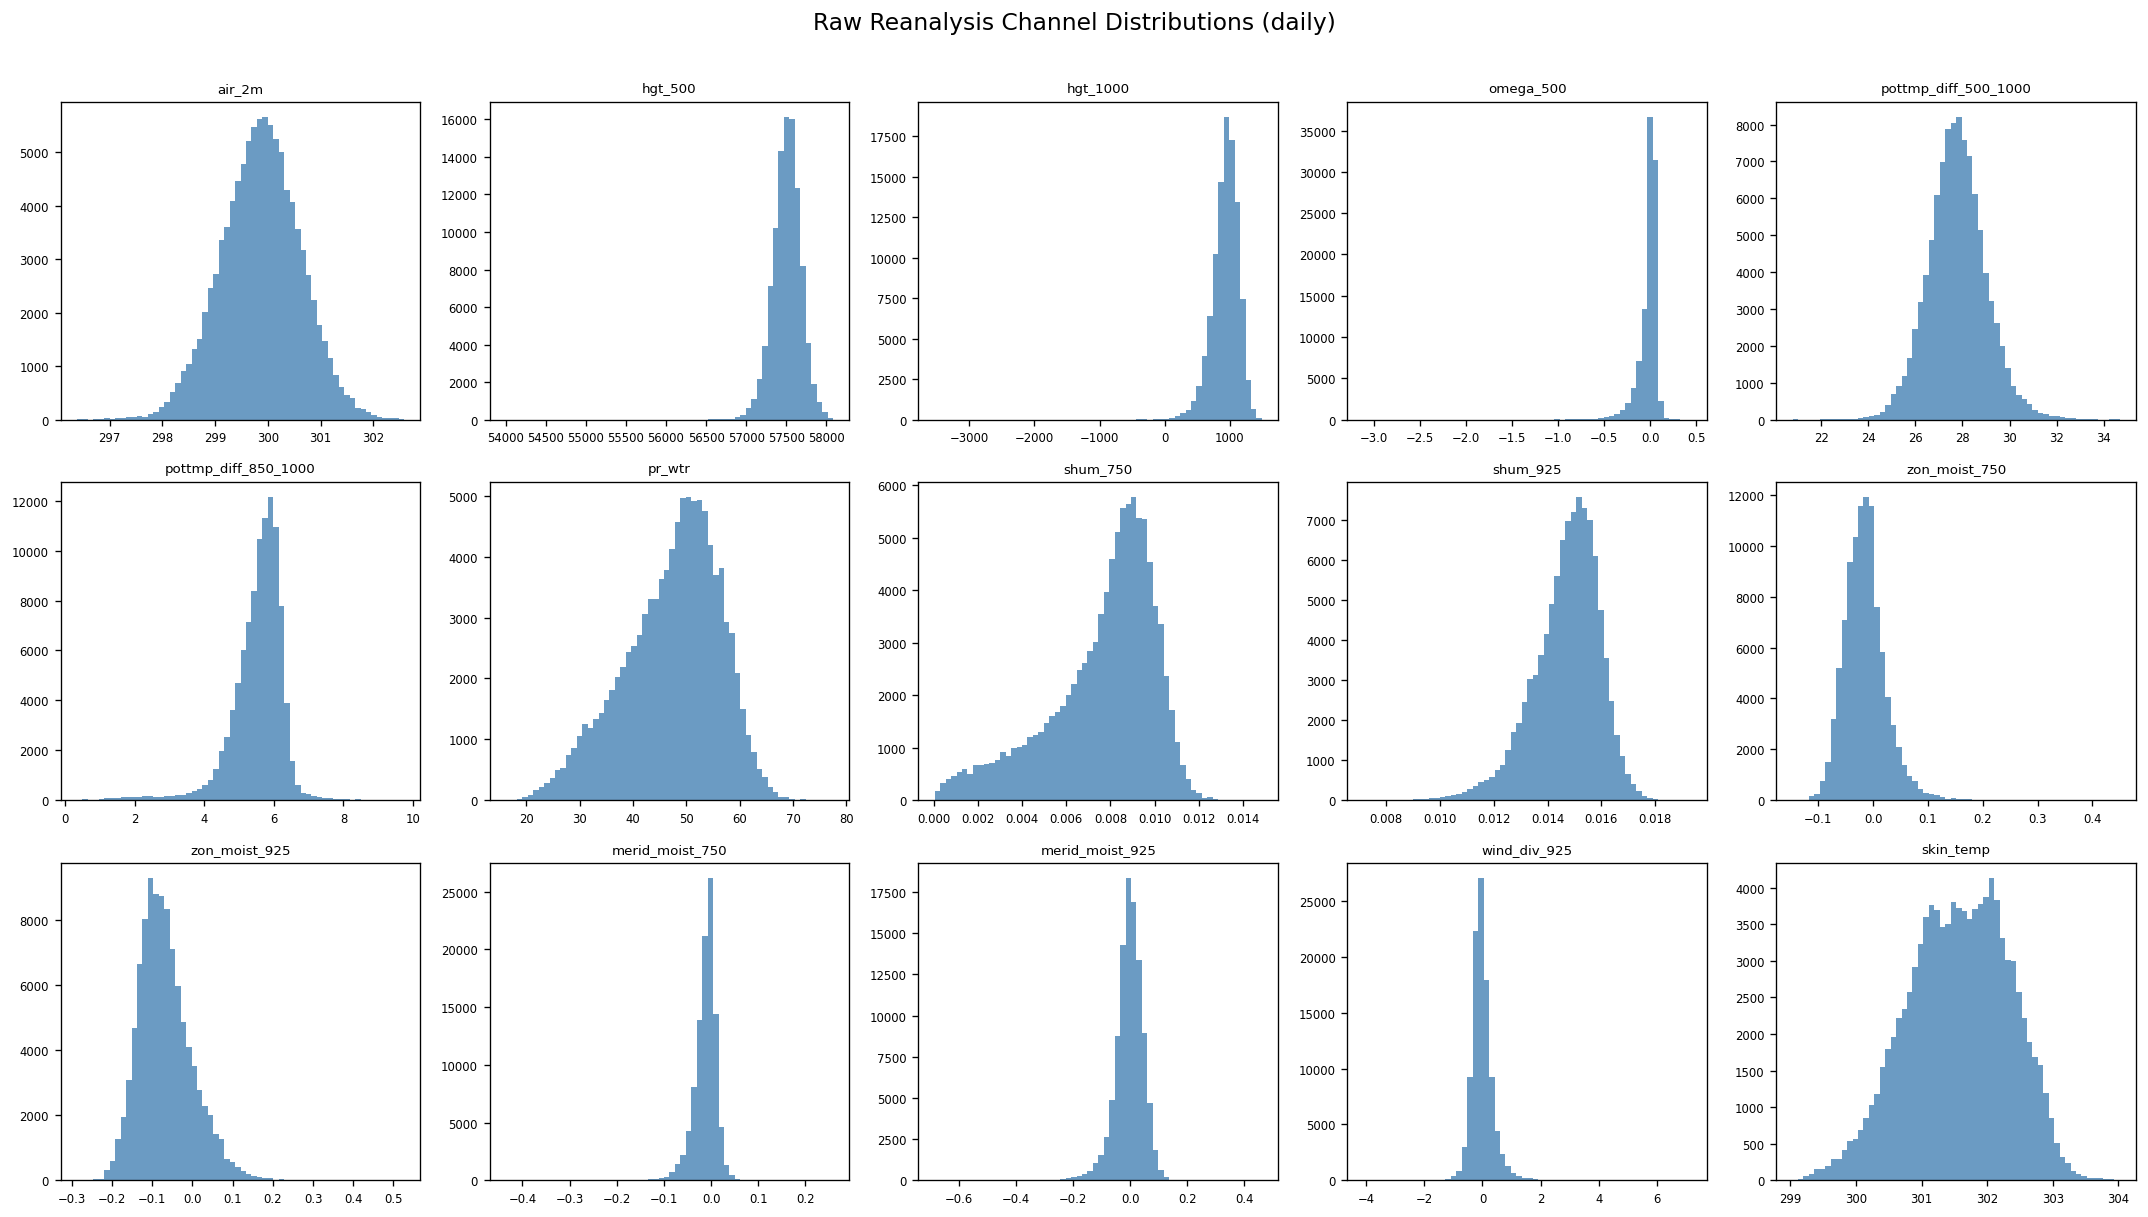

In [5]:
# Per-channel statistics of raw reanalysis patches
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.ravel()
for i in range(min(n_channels, 15)):
    channel = patches[:, i, :, :].flatten()
    # Subsample for speed
    rng = np.random.default_rng(42)
    sample = rng.choice(channel, size=min(100000, len(channel)), replace=False)
    axes[i].hist(sample, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    vname = variables[i] if i < len(variables) else f'ch_{i}'
    axes[i].set_title(f'{vname}', fontsize=8)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Raw Reanalysis Channel Distributions (daily)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

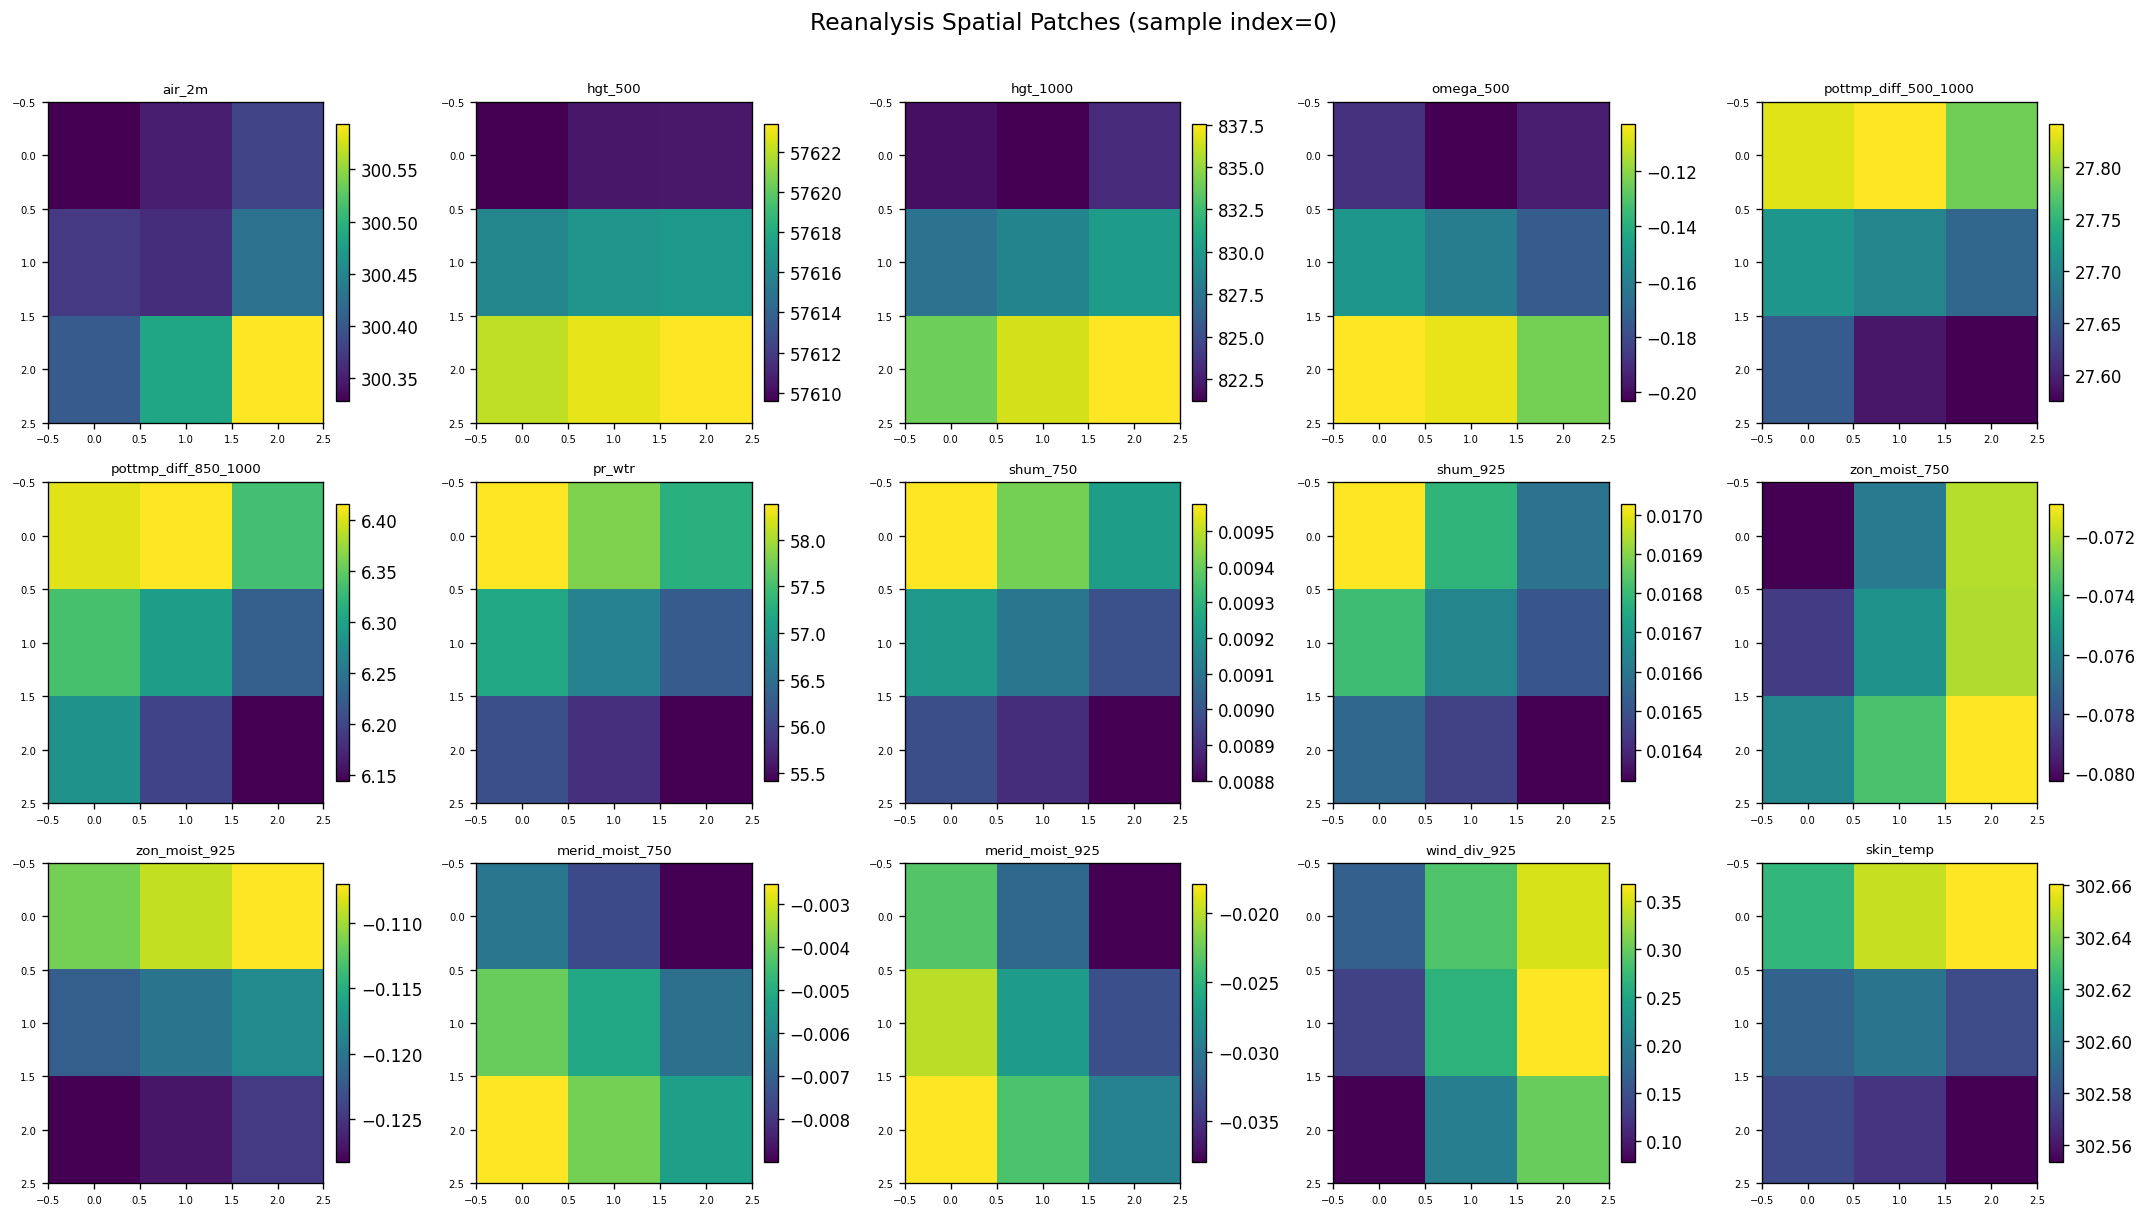

In [6]:
# Sample reanalysis spatial maps for the first observation
n_show = min(n_channels, 15)
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.ravel()
sample_idx = 0
for i in range(n_show):
    im = axes[i].imshow(patches[sample_idx, i], cmap='viridis', aspect='auto')
    vname = variables[i] if i < len(variables) else f'ch_{i}'
    axes[i].set_title(f'{vname}', fontsize=8)
    axes[i].tick_params(labelsize=6)
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(f'Reanalysis Spatial Patches (sample index={sample_idx})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

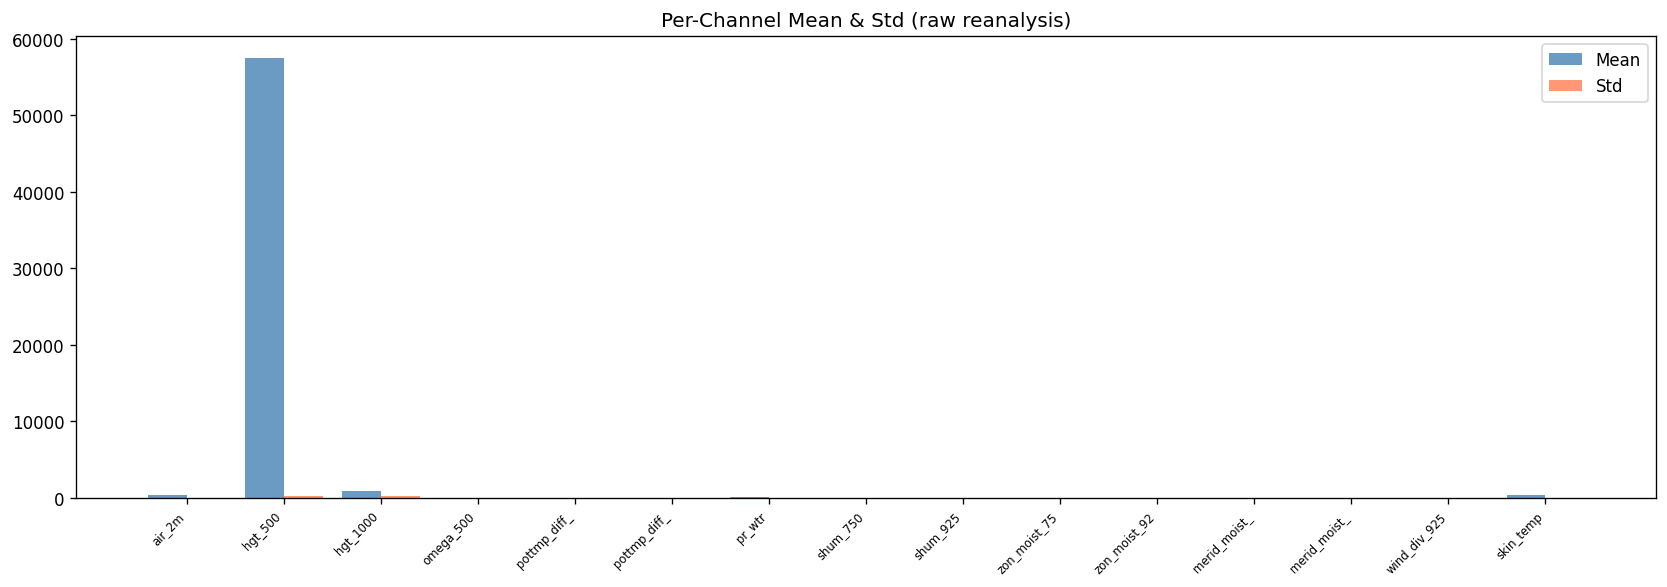

In [7]:
# Per-channel mean and std summary table
ch_means = np.nanmean(patches, axis=(0, 2, 3))
ch_stds = np.nanstd(patches, axis=(0, 2, 3))
ch_mins = np.nanmin(patches.reshape(n_samples, n_channels, -1), axis=(0, 2))
ch_maxs = np.nanmax(patches.reshape(n_samples, n_channels, -1), axis=(0, 2))

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n_channels)
ax.bar(x - 0.2, ch_means, width=0.4, label='Mean', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, ch_stds, width=0.4, label='Std', color='coral', alpha=0.8)
ax.set_xticks(x)
labels = [str(variables[i])[:12] if i < len(variables) else f'ch{i}' for i in range(n_channels)]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_title('Per-Channel Mean & Std (raw reanalysis)')
ax.legend()
plt.tight_layout()
plt.show()

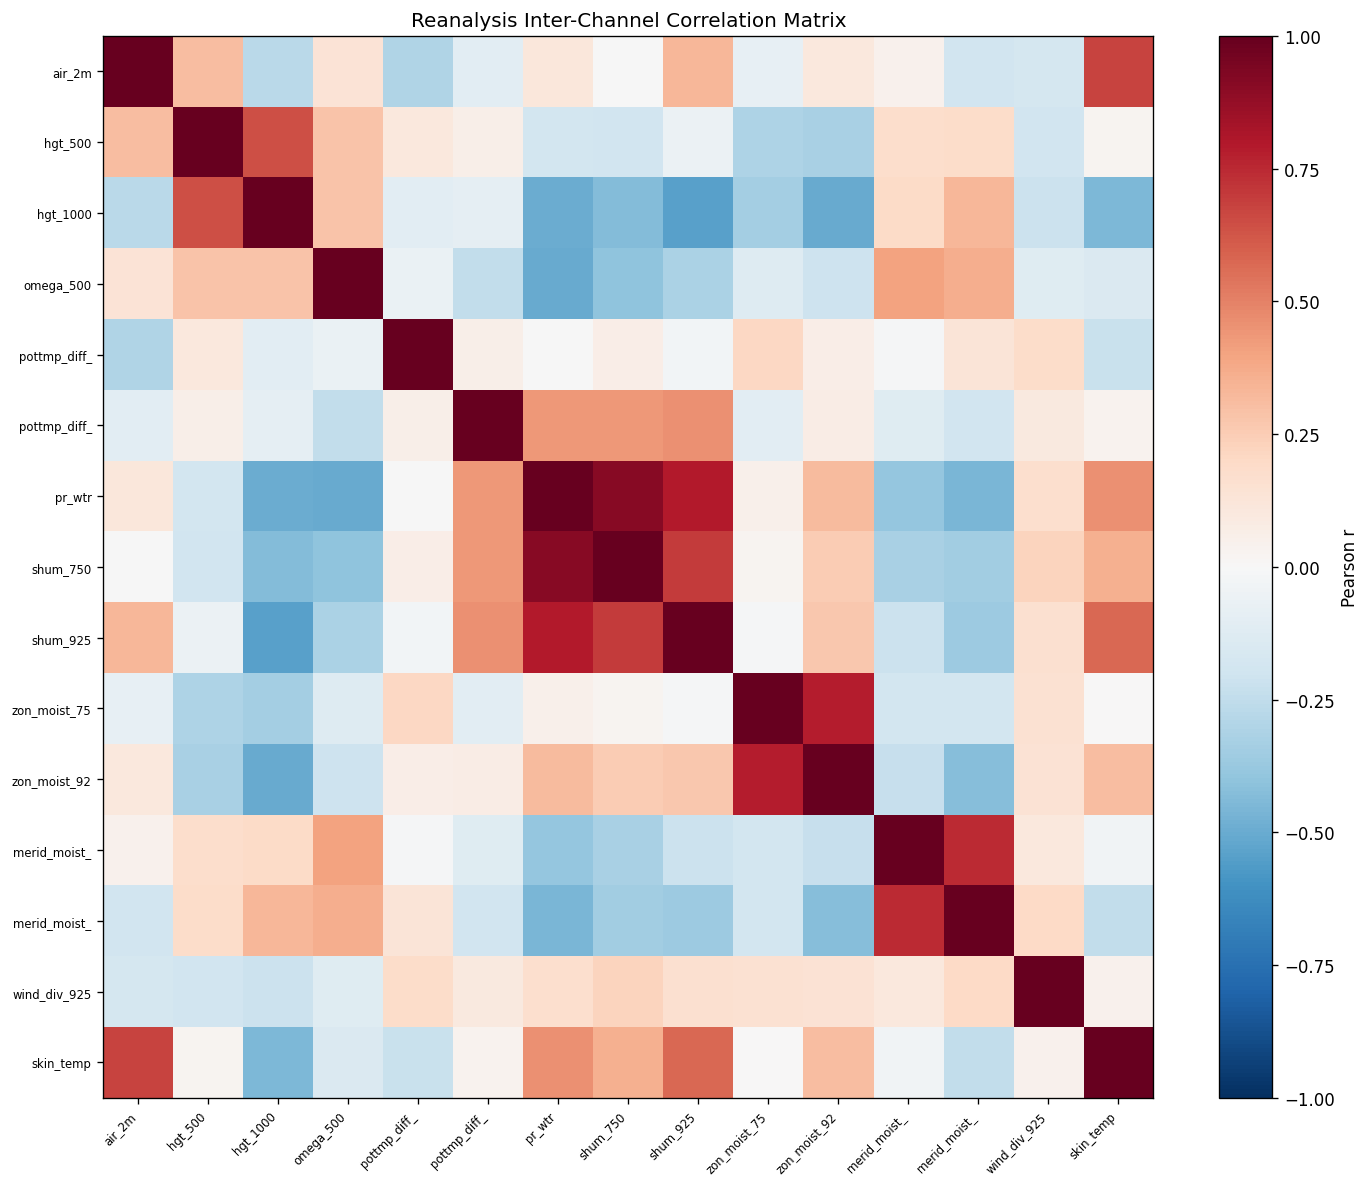

In [8]:
# Inter-channel correlation matrix (using spatial mean per sample)
ch_spatial_mean = np.nanmean(patches, axis=(2, 3))  # (N, C)
corr = np.corrcoef(ch_spatial_mean.T)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(np.arange(n_channels))
ax.set_yticks(np.arange(n_channels))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Reanalysis Inter-Channel Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 2. DEM Features

In [9]:
dem = np.load(FEATURE_DIR / 'dem.npz', allow_pickle=True)
print('Keys:', list(dem.keys()))
for key in dem.keys():
    arr = dem[key]
    print(f'  {key}: shape={arr.shape}, dtype={arr.dtype}')

Keys: ['dem_local_raw', 'dem_regional_raw', 'stations']
  dem_local_raw: shape=(26, 4, 11, 11), dtype=float32
  dem_regional_raw: shape=(26, 4, 25, 25), dtype=float32
  stations: shape=(26,), dtype=object


In [10]:
# DEM station names
dem_stations = dem['stations']
print(f'{len(dem_stations)} stations in DEM:')
for s in dem_stations:
    print(f'  {s}')

26 stations in DEM:
  aasu_UH
  aasufou80
  aasufou90
  afono_UH
  airport5101
  airport80
  aoloafou
  aua
  aunuu
  aunuu_UH
  fagaitua
  iliili
  malaeimi
  malaeimi_1691
  maloata
  masefau
  matatula
  mt_alava
  pioa_afono
  poloa_UH
  satala
  siufaga_WRCC
  toa_ridge_WRCC
  vaipito2000
  vaipito_UH
  vaipito_res


Local DEM: (26, 4, 11, 11) (4 bands)
Regional DEM: (26, 4, 25, 25)


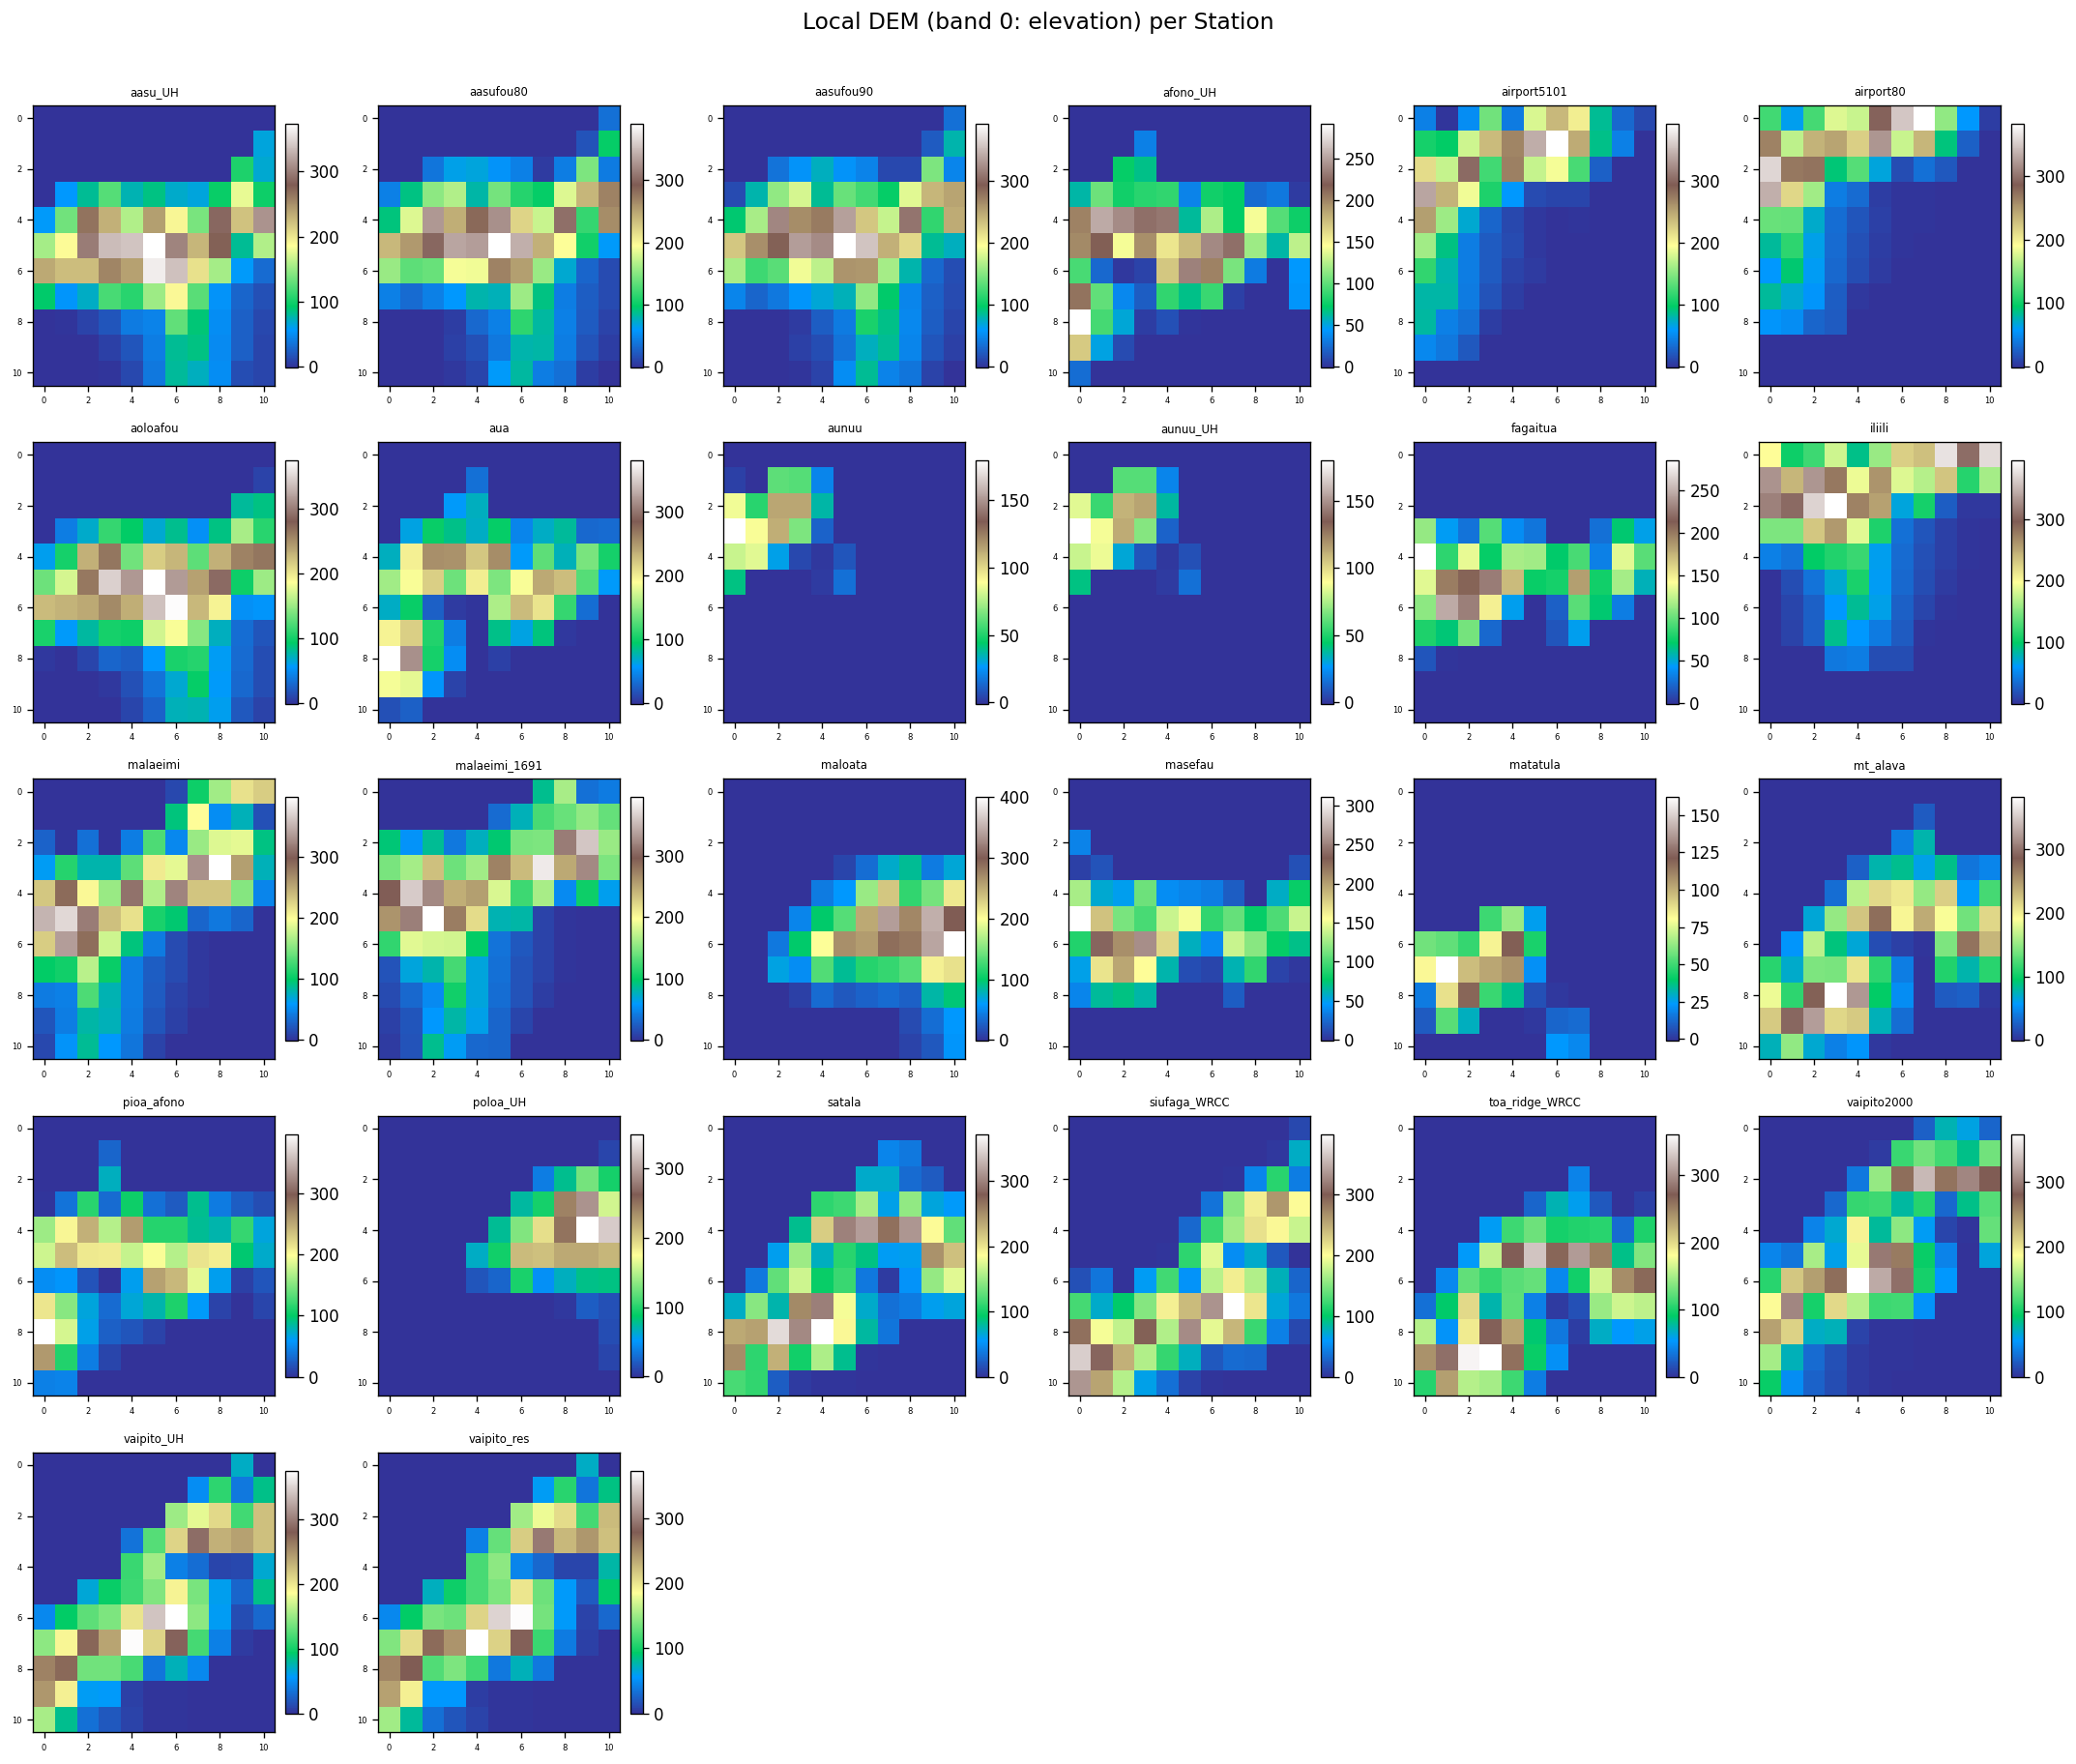

In [11]:
# Visualize local DEM patches for each station (band 0 = elevation)
local_dem = dem['dem_local_raw']
regional_dem = dem['dem_regional_raw']
n_stations_dem = local_dem.shape[0]
n_dem_bands = local_dem.shape[1]
print(f'Local DEM: {local_dem.shape} ({n_dem_bands} bands)')
print(f'Regional DEM: {regional_dem.shape}')

ncols = 6
nrows = int(np.ceil(n_stations_dem / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.ravel()
for i in range(n_stations_dem):
    # Show first band (elevation)
    patch = local_dem[i, 0]
    im = axes[i].imshow(patch, cmap='terrain', aspect='auto')
    axes[i].set_title(f'{dem_stations[i]}', fontsize=7)
    axes[i].tick_params(labelsize=5)
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
for j in range(n_stations_dem, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Local DEM (band 0: elevation) per Station', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

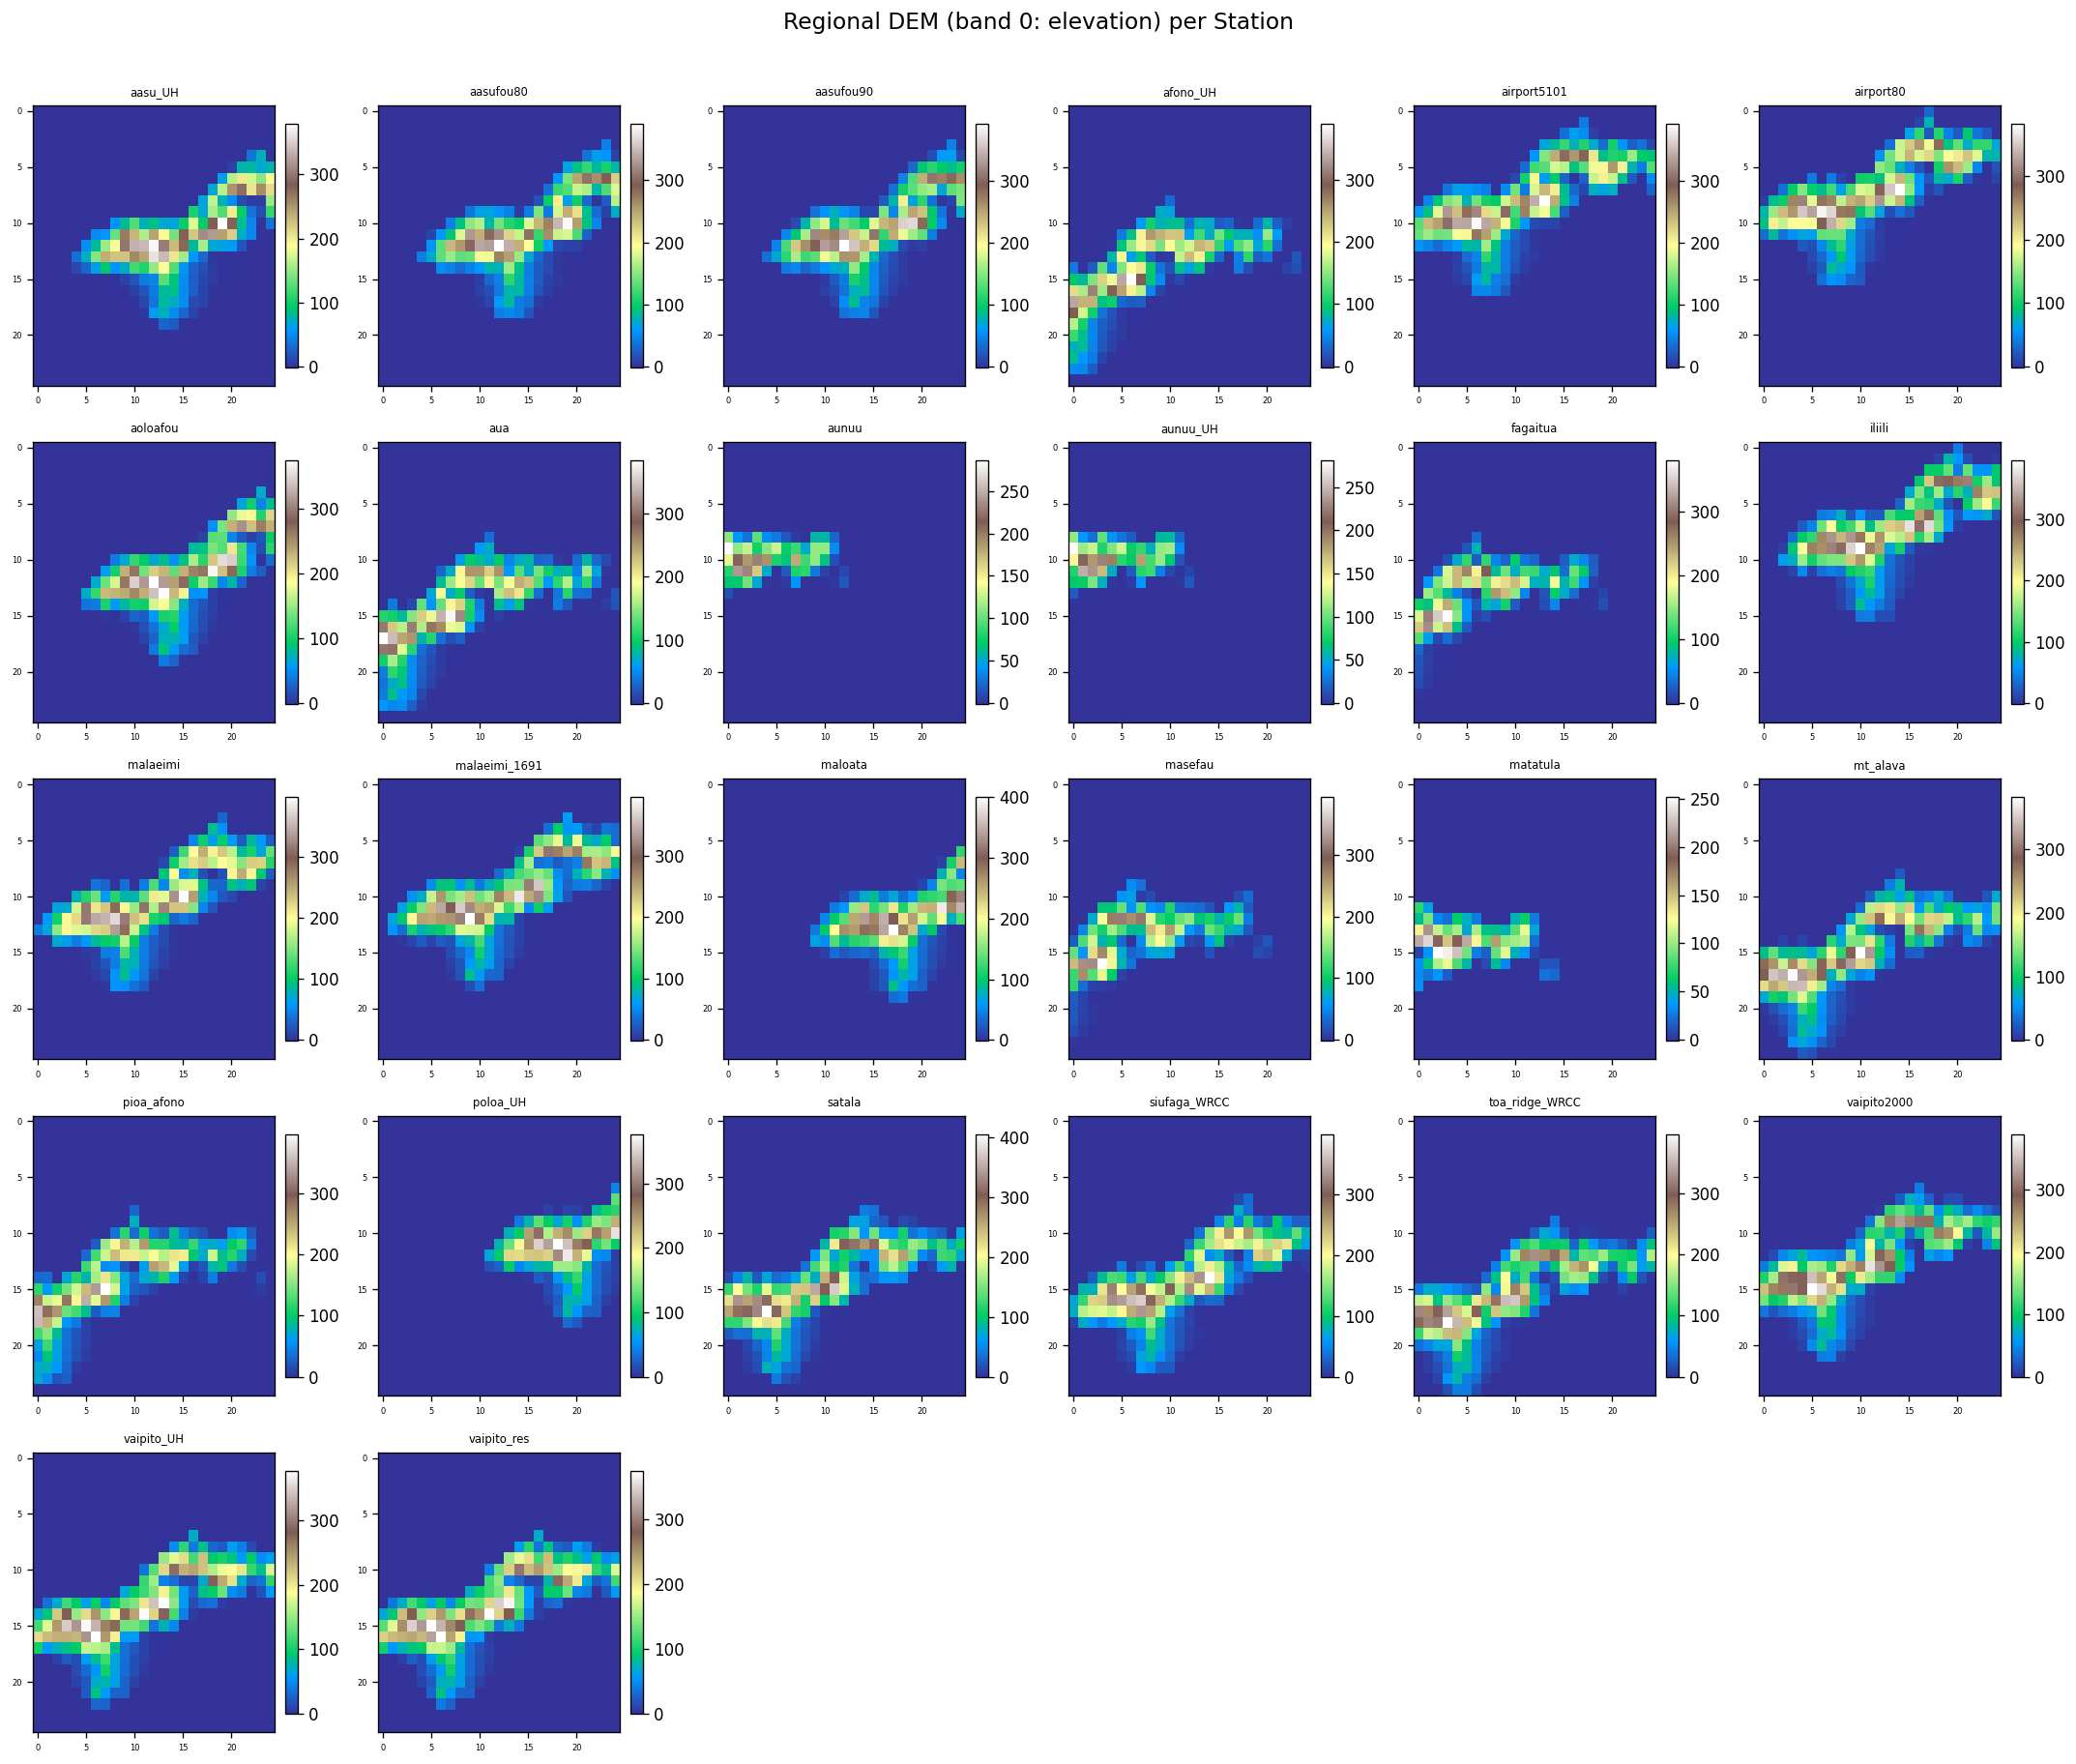

In [12]:
# Visualize regional DEM patches (band 0 = elevation)
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.ravel()
for i in range(n_stations_dem):
    patch = regional_dem[i, 0]
    im = axes[i].imshow(patch, cmap='terrain', aspect='auto')
    axes[i].set_title(f'{dem_stations[i]}', fontsize=7)
    axes[i].tick_params(labelsize=5)
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
for j in range(n_stations_dem, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Regional DEM (band 0: elevation) per Station', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

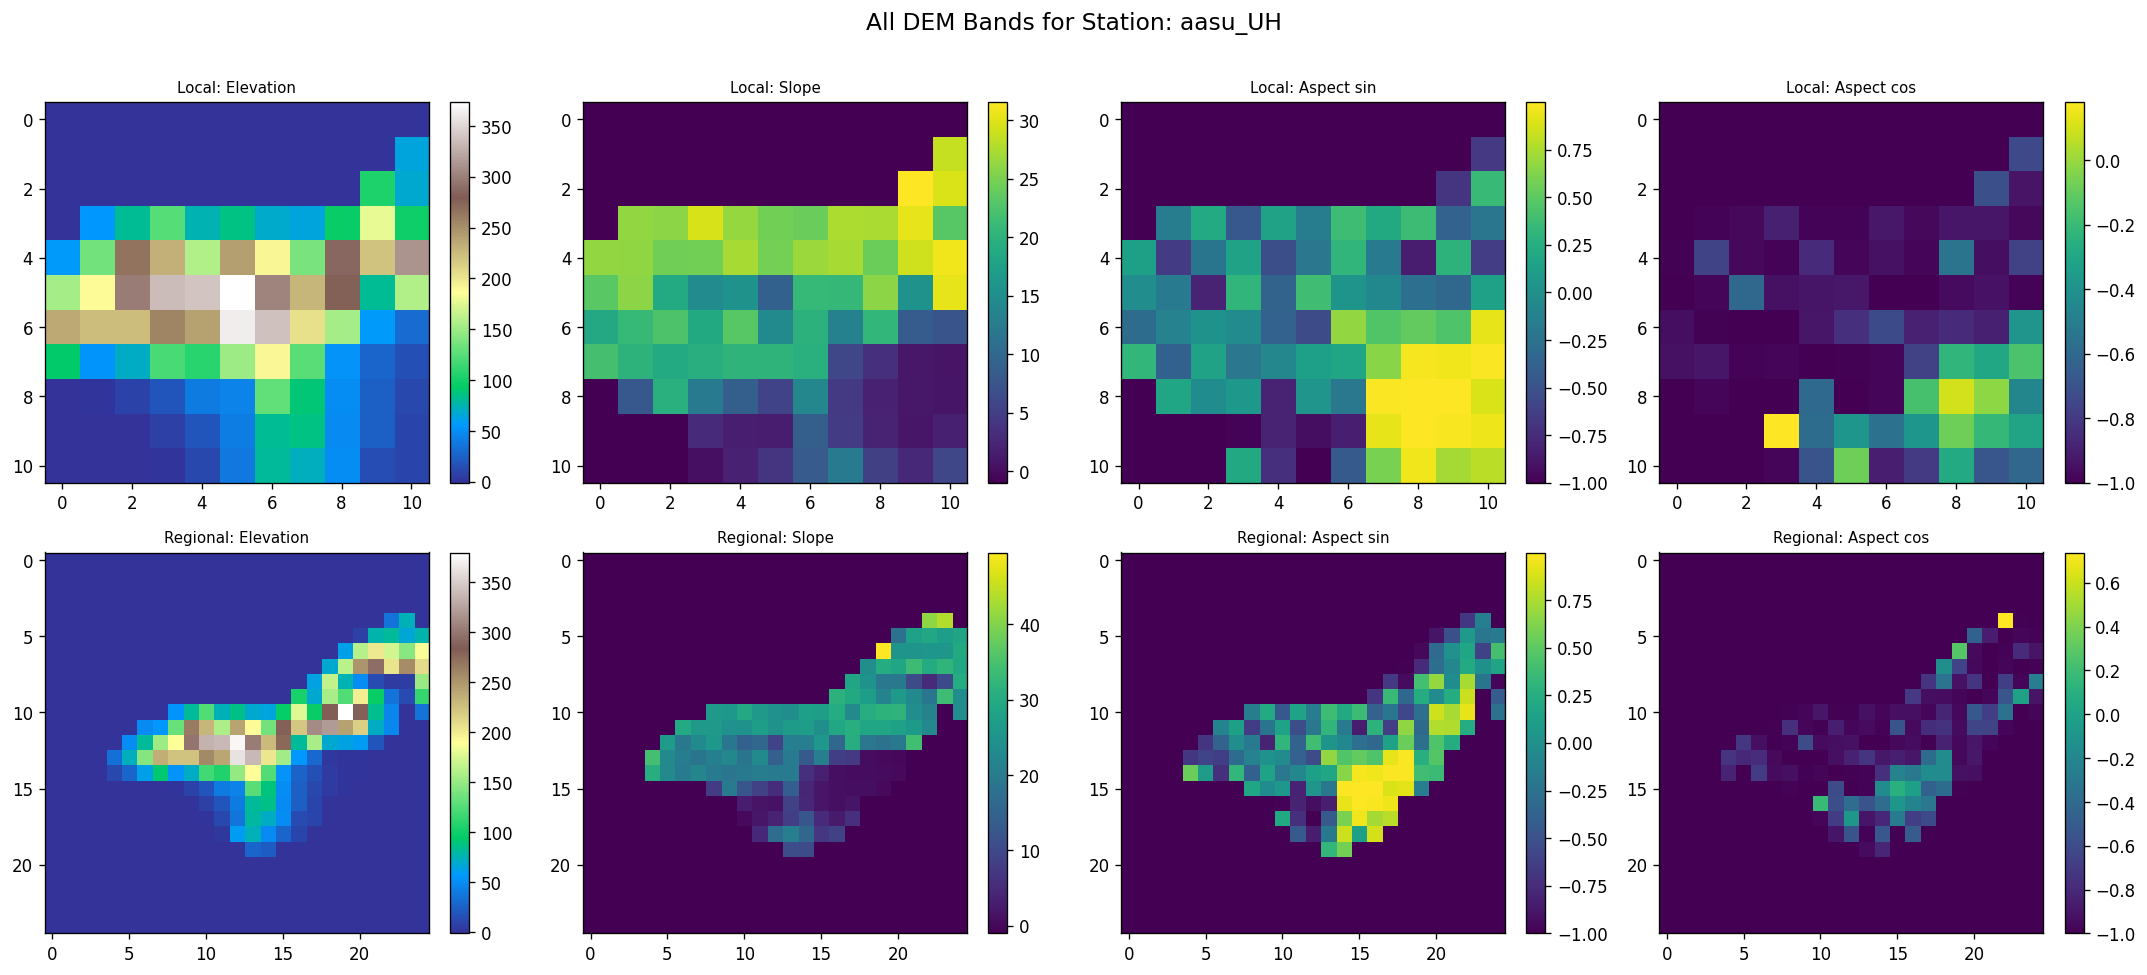

In [13]:
# Compare all 4 DEM bands for a single station
band_names = ['Elevation', 'Slope', 'Aspect sin', 'Aspect cos']
sample_station = 0
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for b in range(n_dem_bands):
    im = axes[0, b].imshow(local_dem[sample_station, b], cmap='terrain' if b == 0 else 'viridis', aspect='auto')
    axes[0, b].set_title(f'Local: {band_names[b]}', fontsize=9)
    plt.colorbar(im, ax=axes[0, b], fraction=0.046)
    im = axes[1, b].imshow(regional_dem[sample_station, b], cmap='terrain' if b == 0 else 'viridis', aspect='auto')
    axes[1, b].set_title(f'Regional: {band_names[b]}', fontsize=9)
    plt.colorbar(im, ax=axes[1, b], fraction=0.046)
fig.suptitle(f'All DEM Bands for Station: {dem_stations[sample_station]}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

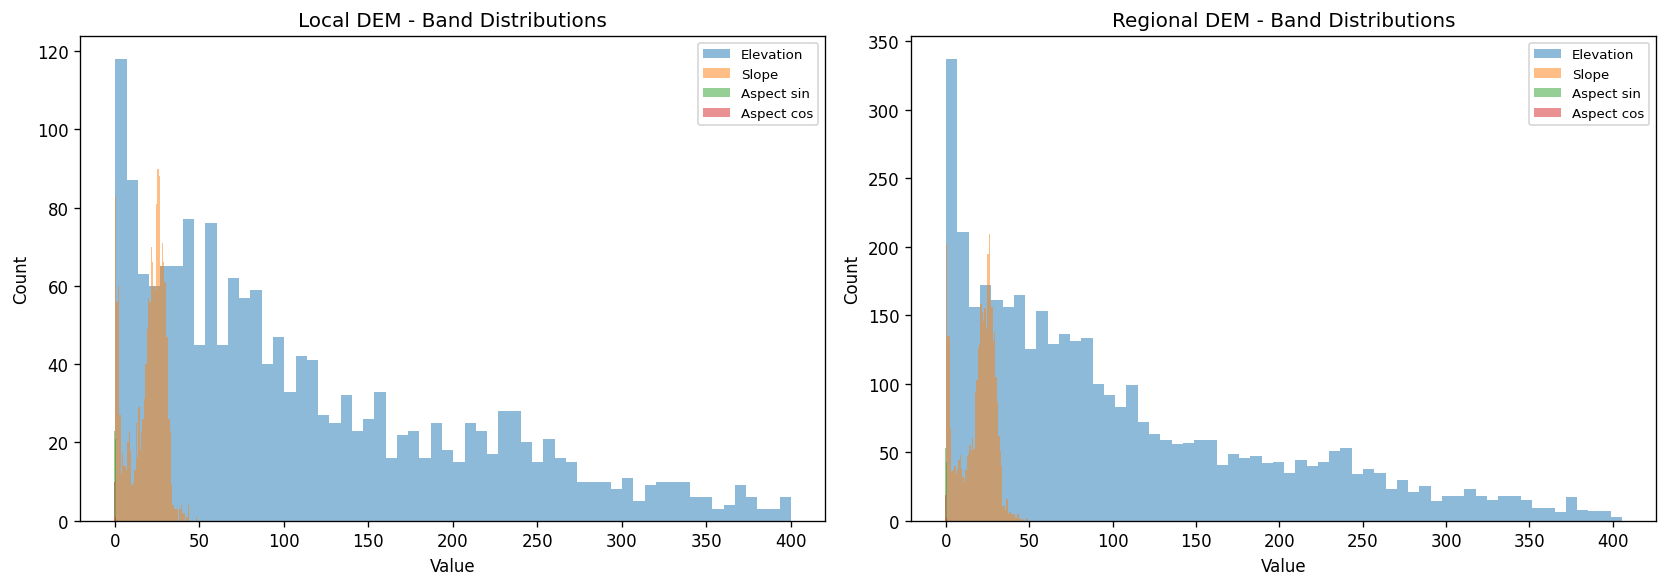

In [14]:
# Distribution of DEM elevation values across all stations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes, [local_dem, regional_dem], ['Local DEM', 'Regional DEM']):
    for b in range(n_dem_bands):
        vals = data[:, b, :, :].flatten()
        vals = vals[vals > -0.5]  # mask ocean
        ax.hist(vals, bins=60, alpha=0.5, label=band_names[b], edgecolor='none')
    ax.set_title(f'{title} - Band Distributions')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. Assembled Weekly Dataset

In [15]:
ds = np.load(DATASET_PATH, allow_pickle=True)
print('Keys:', list(ds.keys()))
for key in ds.keys():
    arr = ds[key]
    print(f'  {key}: shape={arr.shape}, dtype={arr.dtype}')

Keys: ['n_days', 'reanalysis_patches', 'dem_local_raw', 'dem_regional_raw', 'dem_stations', 'station_dem_idx', 'month_onehot', 'rainfall_mm_raw', 'stations', 'years', 'months', 'days', 'variables']
  n_days: shape=(8608,), dtype=int32
  reanalysis_patches: shape=(8608, 30, 3, 3), dtype=float32
  dem_local_raw: shape=(26, 4, 11, 11), dtype=float32
  dem_regional_raw: shape=(26, 4, 25, 25), dtype=float32
  dem_stations: shape=(26,), dtype=object
  station_dem_idx: shape=(8608,), dtype=int32
  month_onehot: shape=(8608, 12), dtype=float32
  rainfall_mm_raw: shape=(8608,), dtype=float32
  stations: shape=(8608,), dtype=object
  years: shape=(8608,), dtype=int32
  months: shape=(8608,), dtype=int32
  days: shape=(8608,), dtype=int32
  variables: shape=(30,), dtype=object


In [16]:
# Extract core arrays
rainfall = ds['rainfall_mm_raw'].astype(float)
stations = ds['stations'].astype(str)
years = ds['years'].astype(int)
months = ds['months'].astype(int)
month_onehot = ds['month_onehot']
climate_patches = ds['reanalysis_patches']
station_dem_idx = ds['station_dem_idx']

# Get variable names if available
ds_variables = ds.get('variables', np.array([]))
if len(ds_variables) > 0:
    ds_variables = ds_variables.astype(str) if ds_variables.dtype.kind != 'U' else ds_variables

unique_stations = np.unique(stations)
unique_years = np.unique(years)
n_samples = len(rainfall)

print(f'Total samples: {n_samples}')
print(f'Unique stations: {len(unique_stations)}')
print(f'Year range: {years.min()}-{years.max()} ({len(unique_years)} years)')
print(f'Climate patches shape: {climate_patches.shape}')
print(f'Month one-hot shape: {month_onehot.shape}')
print(f'Rainfall range: {rainfall.min():.1f} - {rainfall.max():.1f} mm')
print(f'Rainfall mean: {rainfall.mean():.1f} mm, median: {np.median(rainfall):.1f} mm')

Total samples: 8608
Unique stations: 26
Year range: 1980-2024 (42 years)
Climate patches shape: (8608, 30, 3, 3)
Month one-hot shape: (8608, 12)
Rainfall range: 0.0 - 812.8 mm
Rainfall mean: 73.9 mm, median: 52.1 mm


### 3.1 Rainfall Distribution

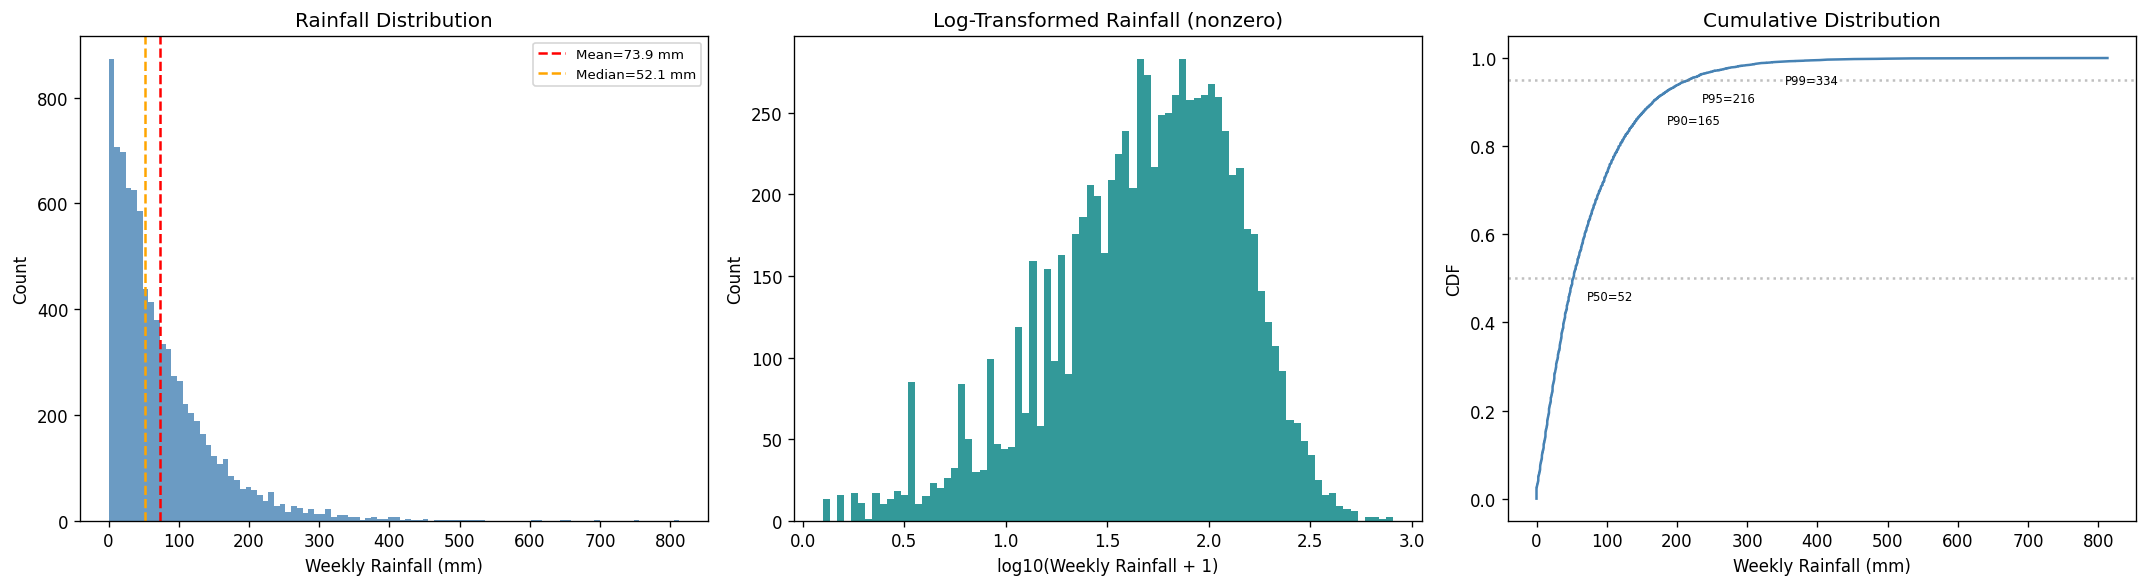

Zero rainfall weeks: 216 (2.5%)
  P25: 22.9 mm
  P50: 52.1 mm
  P75: 102.6 mm
  P90: 165.4 mm
  P95: 215.9 mm
  P99: 334.2 mm


In [17]:
# Overall rainfall distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw histogram
axes[0].hist(rainfall, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(rainfall.mean(), color='red', ls='--', label=f'Mean={rainfall.mean():.1f} mm')
axes[0].axvline(np.median(rainfall), color='orange', ls='--', label=f'Median={np.median(rainfall):.1f} mm')
axes[0].set_xlabel('Weekly Rainfall (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Rainfall Distribution')
axes[0].legend(fontsize=8)

# Log-scale histogram
positive_rain = rainfall[rainfall > 0]
axes[1].hist(np.log10(positive_rain + 1), bins=80, color='teal', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('log10(Weekly Rainfall + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Rainfall (nonzero)')

# CDF
sorted_rain = np.sort(rainfall)
cdf = np.arange(1, len(sorted_rain) + 1) / len(sorted_rain)
axes[2].plot(sorted_rain, cdf, color='steelblue', lw=1.5)
axes[2].set_xlabel('Weekly Rainfall (mm)')
axes[2].set_ylabel('CDF')
axes[2].set_title('Cumulative Distribution')
axes[2].axhline(0.5, color='gray', ls=':', alpha=0.5)
axes[2].axhline(0.95, color='gray', ls=':', alpha=0.5)

# Annotate key percentiles
for q in [50, 90, 95, 99]:
    val = np.percentile(rainfall, q)
    axes[2].annotate(f'P{q}={val:.0f}', xy=(val, q/100), fontsize=7,
                     xytext=(val + 20, q/100 - 0.05))

plt.tight_layout()
plt.show()

# Key statistics
print(f'Zero rainfall weeks: {np.sum(rainfall == 0)} ({100*np.mean(rainfall == 0):.1f}%)')
for q in [25, 50, 75, 90, 95, 99]:
    print(f'  P{q}: {np.percentile(rainfall, q):.1f} mm')

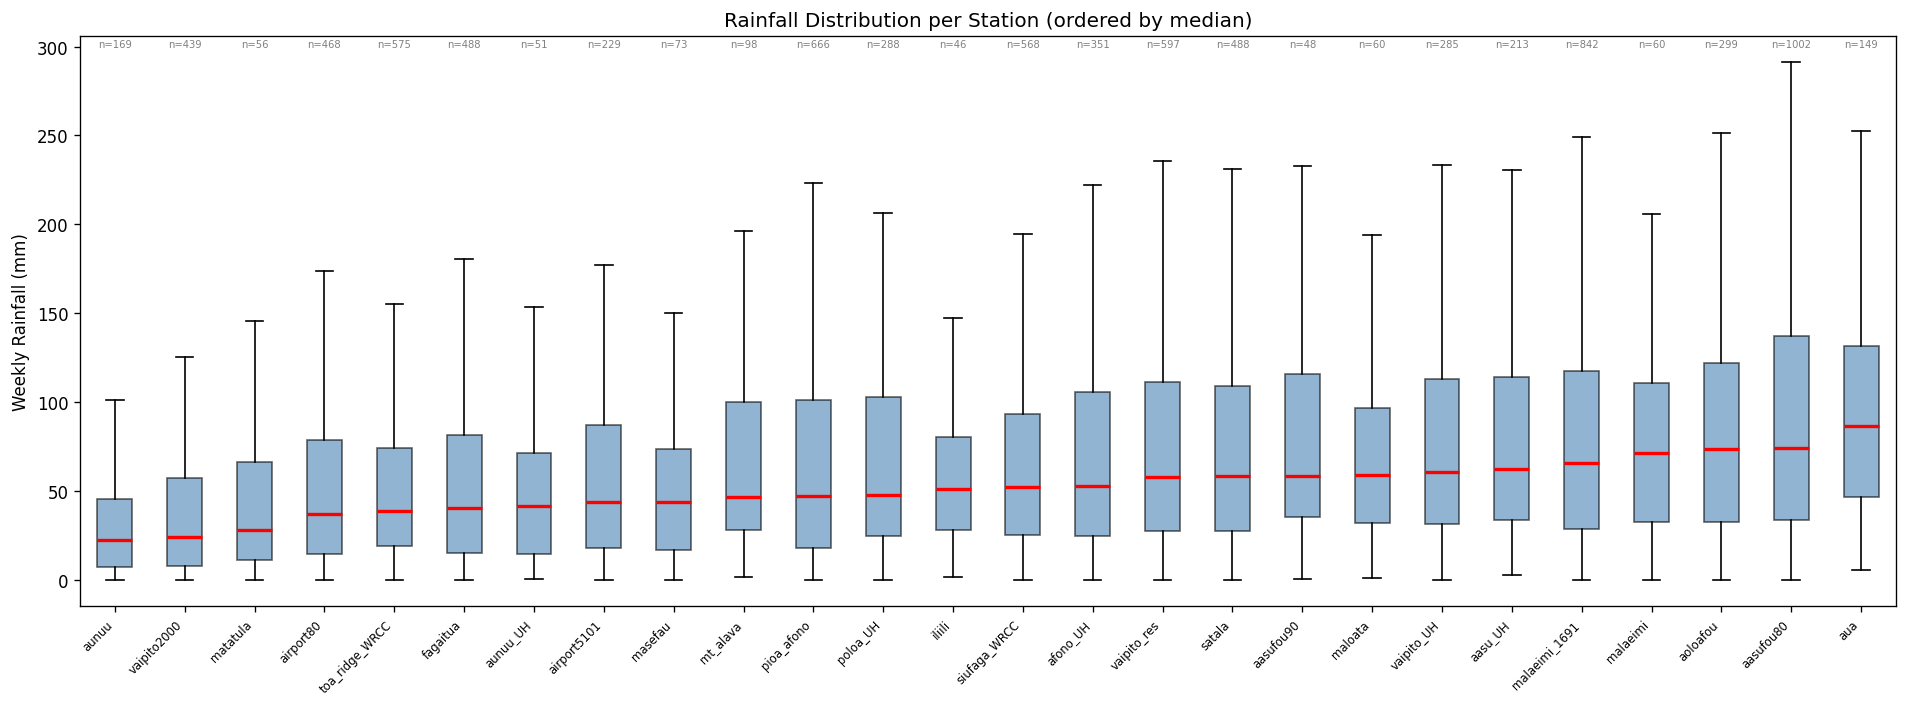

In [18]:
# Rainfall distribution per station (boxplot)
station_order = sorted(unique_stations, key=lambda s: np.median(rainfall[stations == s]))
rain_by_station = [rainfall[stations == s] for s in station_order]

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot(rain_by_station, vert=True, patch_artist=True, showfliers=False,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', lw=2))
ax.set_xticks(range(1, len(station_order) + 1))
ax.set_xticklabels(station_order, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Weekly Rainfall (mm)')
ax.set_title('Rainfall Distribution per Station (ordered by median)')

# Annotate sample counts
for i, s in enumerate(station_order):
    n = np.sum(stations == s)
    ax.text(i + 1, ax.get_ylim()[1] * 0.98, f'n={n}', ha='center', fontsize=6, color='gray')

plt.tight_layout()
plt.show()

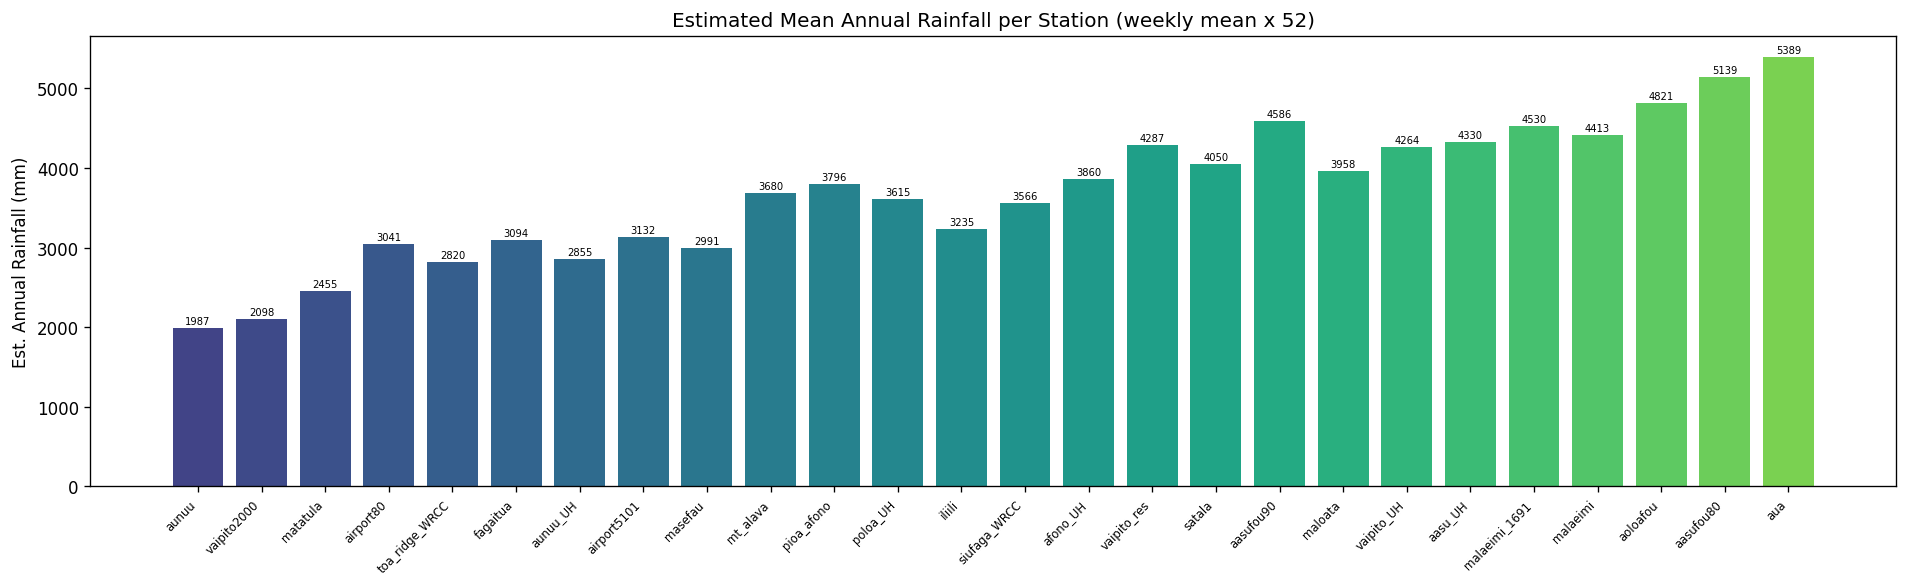

In [19]:
# Per-station mean annual rainfall estimate (weekly sum -> annual)
fig, ax = plt.subplots(figsize=(16, 5))
station_means = []
for s in station_order:
    mask = stations == s
    # Approximate annual rainfall: mean weekly * 52
    annual_est = rainfall[mask].mean() * 52
    station_means.append(annual_est)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(station_order)))
bars = ax.bar(range(len(station_order)), station_means, color=colors)
ax.set_xticks(range(len(station_order)))
ax.set_xticklabels(station_order, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Est. Annual Rainfall (mm)')
ax.set_title('Estimated Mean Annual Rainfall per Station (weekly mean x 52)')
for i, v in enumerate(station_means):
    ax.text(i, v + 50, f'{v:.0f}', ha='center', fontsize=6)
plt.tight_layout()
plt.show()

### 3.2 Temporal Patterns

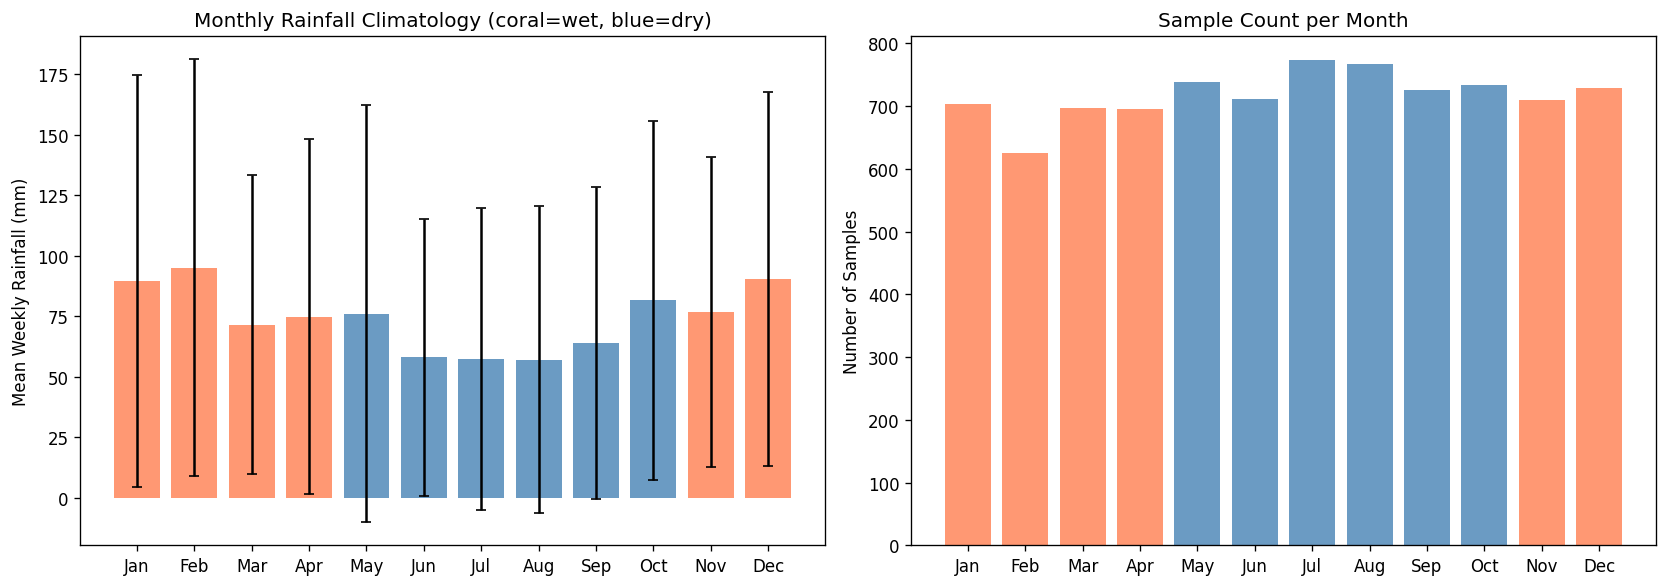

In [20]:
# Monthly rainfall climatology (wet vs dry season: wet=Nov-Apr, dry=May-Oct)
monthly_mean = np.zeros(12)
monthly_std = np.zeros(12)
monthly_count = np.zeros(12)
for m in range(1, 13):
    mask = months == m
    monthly_mean[m-1] = rainfall[mask].mean()
    monthly_std[m-1] = rainfall[mask].std()
    monthly_count[m-1] = mask.sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
wet_months = [10, 11, 0, 1, 2, 3]  # Nov-Apr (0-indexed)
dry_months = [4, 5, 6, 7, 8, 9]    # May-Oct
colors_monthly = ['coral' if i in wet_months else 'steelblue' for i in range(12)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(12), monthly_mean, yerr=monthly_std, color=colors_monthly, alpha=0.8,
            capsize=3, edgecolor='none')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('Mean Weekly Rainfall (mm)')
axes[0].set_title('Monthly Rainfall Climatology (coral=wet, blue=dry)')

axes[1].bar(range(12), monthly_count, color=colors_monthly, alpha=0.8, edgecolor='none')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sample Count per Month')

plt.tight_layout()
plt.show()

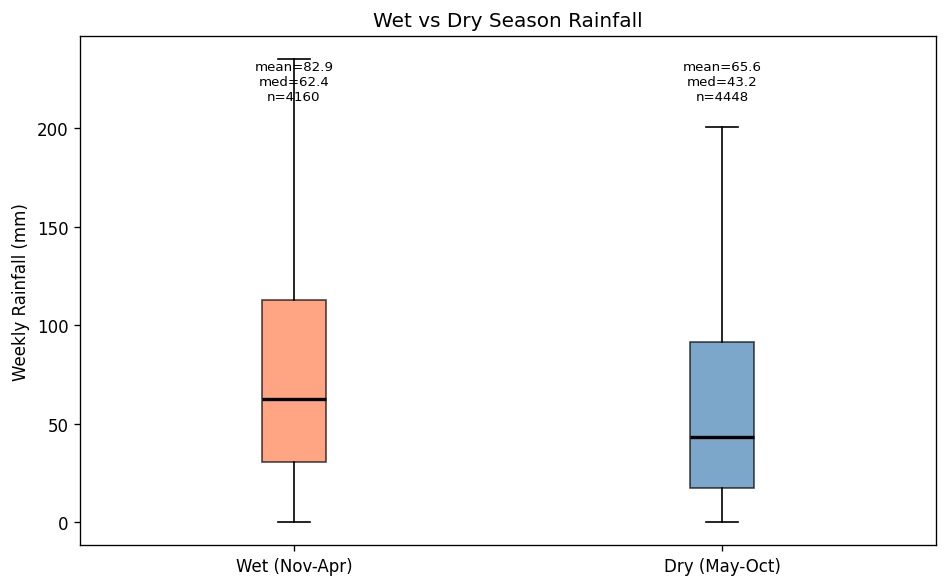

In [21]:
# Wet vs dry season rainfall comparison
is_wet = np.isin(months, [11, 12, 1, 2, 3, 4])
is_dry = ~is_wet

fig, ax = plt.subplots(figsize=(8, 5))
data_seasons = [rainfall[is_wet], rainfall[is_dry]]
bp = ax.boxplot(data_seasons, labels=['Wet (Nov-Apr)', 'Dry (May-Oct)'],
                patch_artist=True, showfliers=False,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
ax.set_ylabel('Weekly Rainfall (mm)')
ax.set_title('Wet vs Dry Season Rainfall')
for i, season_data in enumerate(data_seasons):
    ax.text(i + 1, ax.get_ylim()[1] * 0.95,
            f'mean={season_data.mean():.1f}\nmed={np.median(season_data):.1f}\nn={len(season_data)}',
            ha='center', fontsize=8, va='top')
plt.tight_layout()
plt.show()

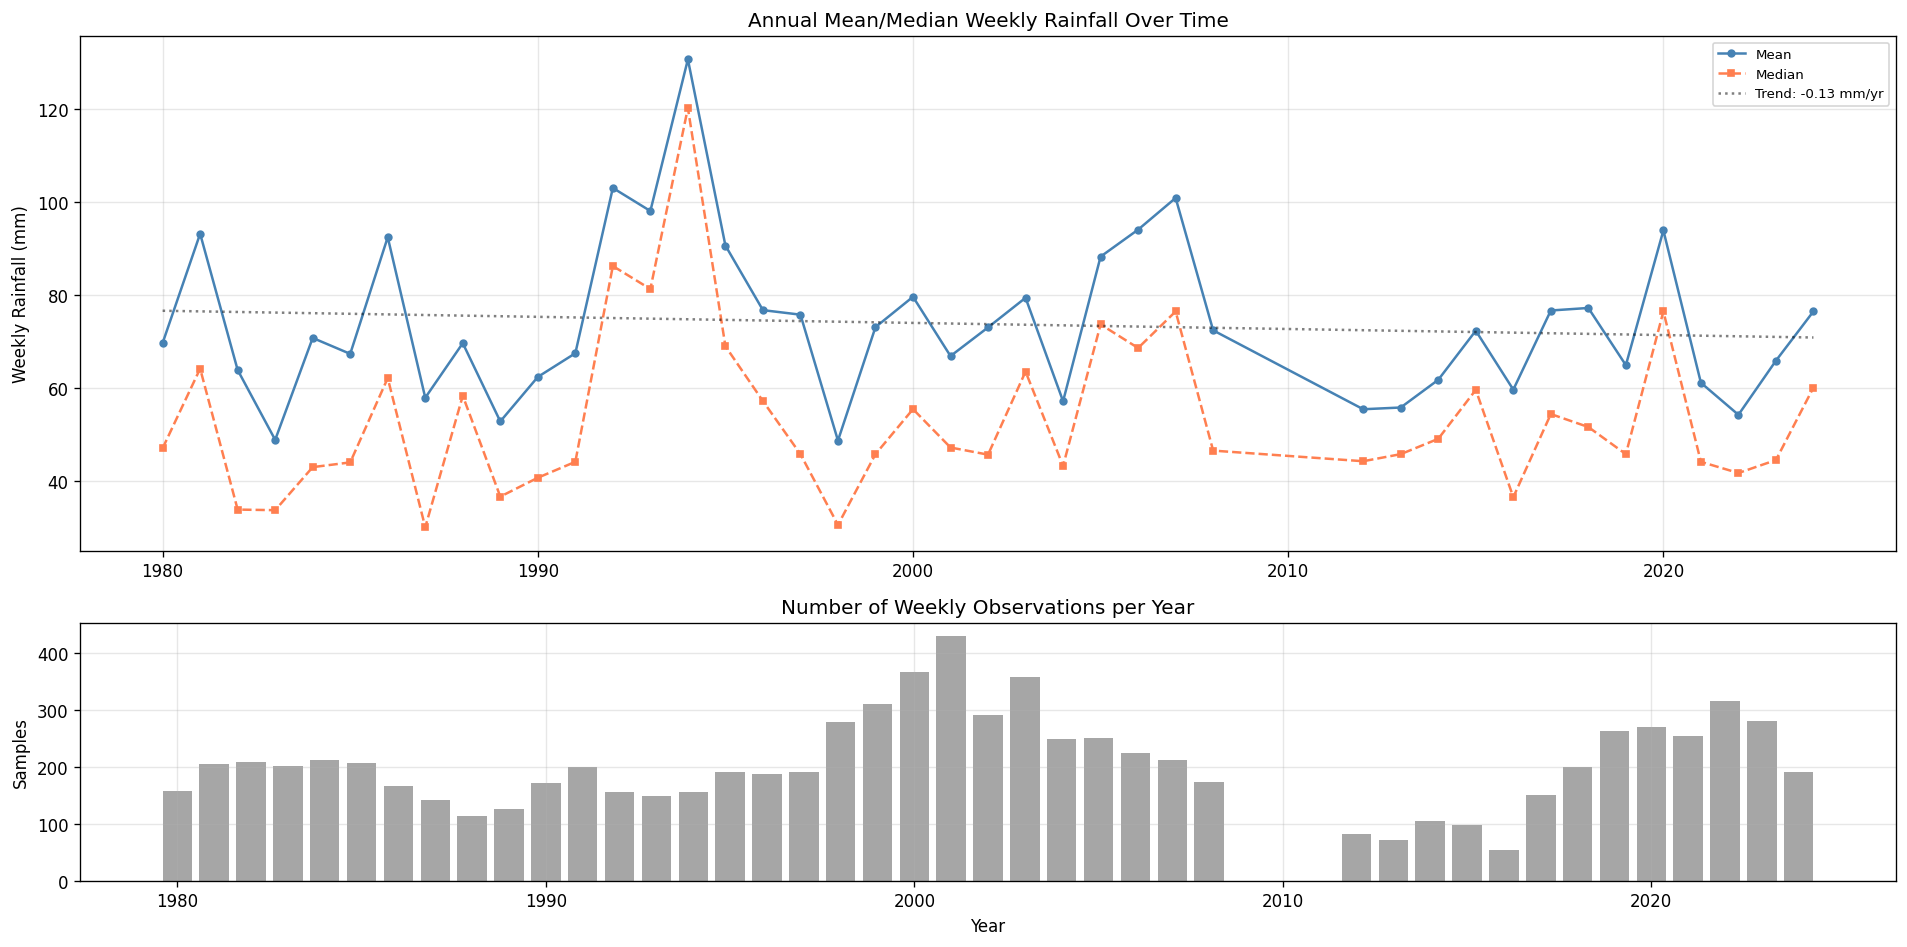

In [22]:
# Annual mean rainfall time series
annual_means = []
annual_medians = []
annual_counts = []
for y in unique_years:
    mask = years == y
    annual_means.append(rainfall[mask].mean())
    annual_medians.append(np.median(rainfall[mask]))
    annual_counts.append(mask.sum())

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(unique_years, annual_means, 'o-', color='steelblue', ms=4, label='Mean')
axes[0].plot(unique_years, annual_medians, 's--', color='coral', ms=4, label='Median')
# Add trend line
z = np.polyfit(unique_years, annual_means, 1)
axes[0].plot(unique_years, np.polyval(z, unique_years), 'k:', alpha=0.5,
             label=f'Trend: {z[0]:.2f} mm/yr')
axes[0].set_ylabel('Weekly Rainfall (mm)')
axes[0].set_title('Annual Mean/Median Weekly Rainfall Over Time')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].bar(unique_years, annual_counts, color='gray', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Samples')
axes[1].set_title('Number of Weekly Observations per Year')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

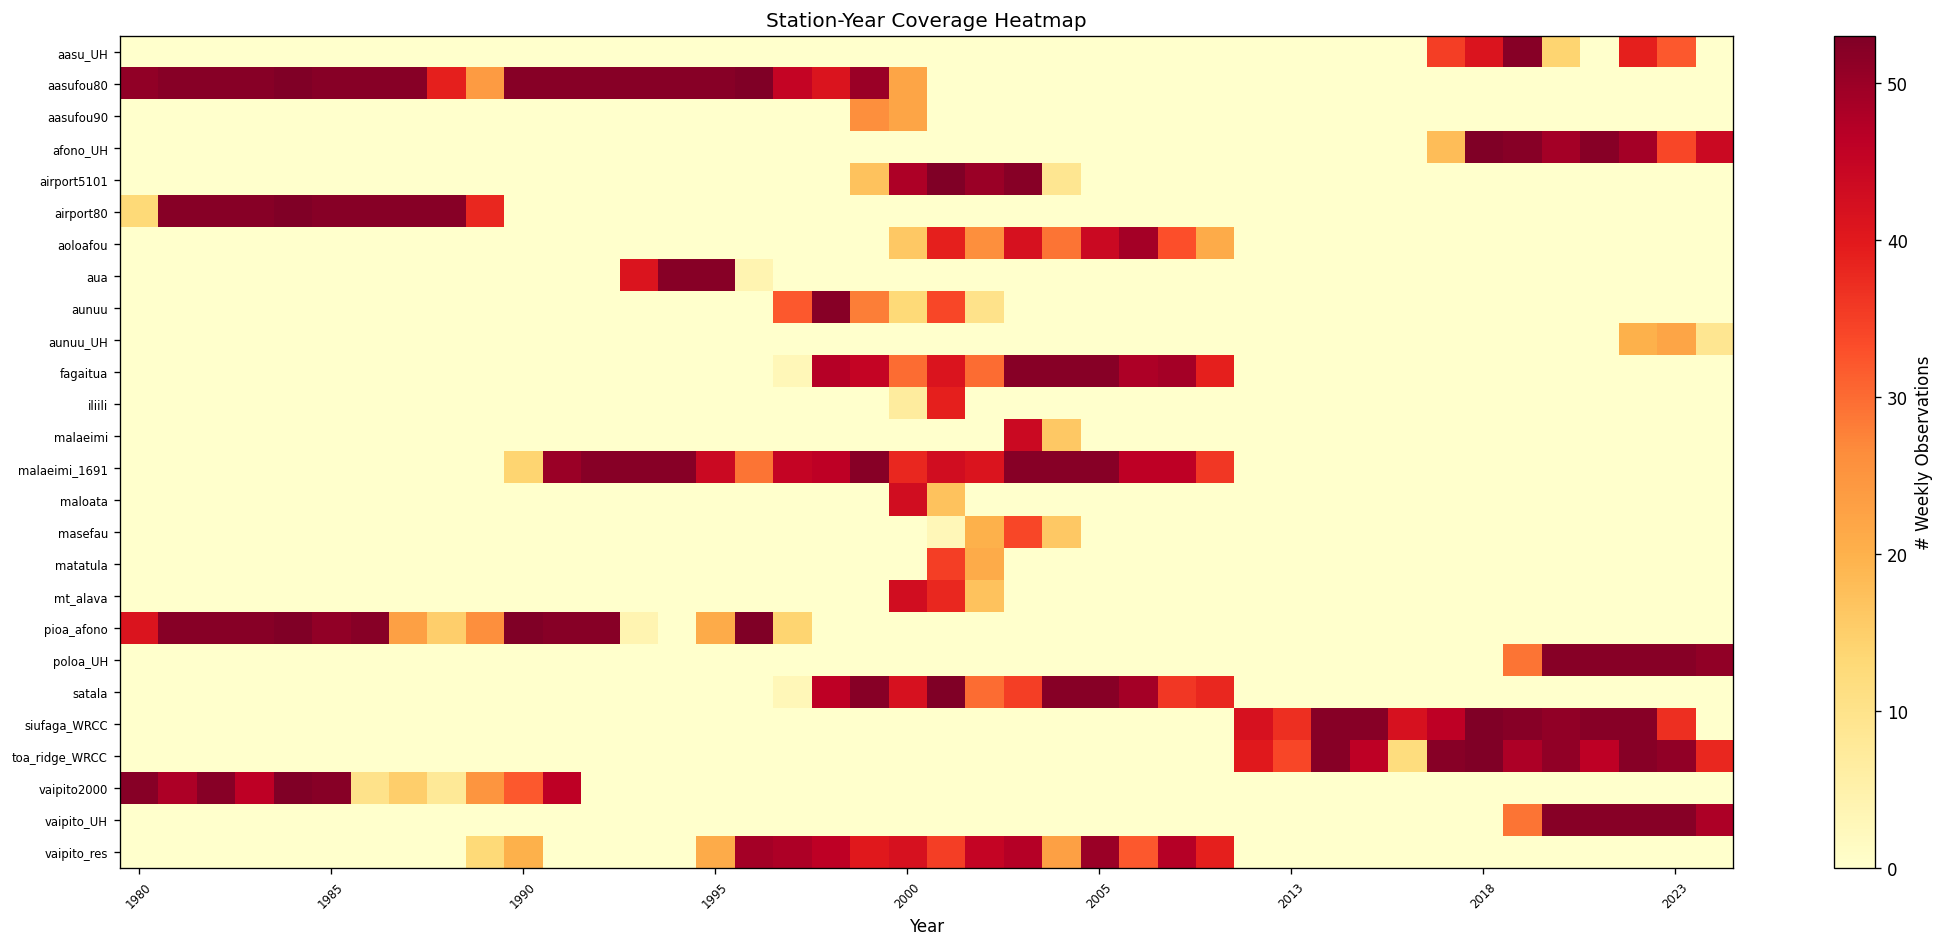

In [23]:
# Station temporal coverage heatmap
fig, ax = plt.subplots(figsize=(18, 8))
coverage = np.zeros((len(unique_stations), len(unique_years)))
for i, s in enumerate(sorted(unique_stations)):
    for j, y in enumerate(unique_years):
        coverage[i, j] = np.sum((stations == s) & (years == y))

im = ax.imshow(coverage, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(unique_stations)))
ax.set_yticklabels(sorted(unique_stations), fontsize=7)
# Show every 5th year as tick
year_ticks = np.arange(0, len(unique_years), 5)
ax.set_xticks(year_ticks)
ax.set_xticklabels(unique_years[year_ticks], fontsize=7, rotation=45)
plt.colorbar(im, ax=ax, label='# Weekly Observations')
ax.set_title('Station-Year Coverage Heatmap')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

### 3.3 Weekly Climate Patches (Assembled)

In [24]:
# Weekly climate patches: shape and channel info
n_week, n_ch_week, h_week, w_week = climate_patches.shape
print(f'Weekly climate patches: {climate_patches.shape}')
print(f'  {n_ch_week} channels = {n_ch_week // 2} variables x 2 (mean + std)')
if len(ds_variables) > 0:
    print(f'  Variables: {list(ds_variables)}')

Weekly climate patches: (8608, 30, 3, 3)
  30 channels = 15 variables x 2 (mean + std)
  Variables: [np.str_('air_2m_mean'), np.str_('hgt_500_mean'), np.str_('hgt_1000_mean'), np.str_('omega_500_mean'), np.str_('pottmp_diff_500_1000_mean'), np.str_('pottmp_diff_850_1000_mean'), np.str_('pr_wtr_mean'), np.str_('shum_750_mean'), np.str_('shum_925_mean'), np.str_('zon_moist_750_mean'), np.str_('zon_moist_925_mean'), np.str_('merid_moist_750_mean'), np.str_('merid_moist_925_mean'), np.str_('wind_div_925_mean'), np.str_('skin_temp_mean'), np.str_('air_2m_std'), np.str_('hgt_500_std'), np.str_('hgt_1000_std'), np.str_('omega_500_std'), np.str_('pottmp_diff_500_1000_std'), np.str_('pottmp_diff_850_1000_std'), np.str_('pr_wtr_std'), np.str_('shum_750_std'), np.str_('shum_925_std'), np.str_('zon_moist_750_std'), np.str_('zon_moist_925_std'), np.str_('merid_moist_750_std'), np.str_('merid_moist_925_std'), np.str_('wind_div_925_std'), np.str_('skin_temp_std')]


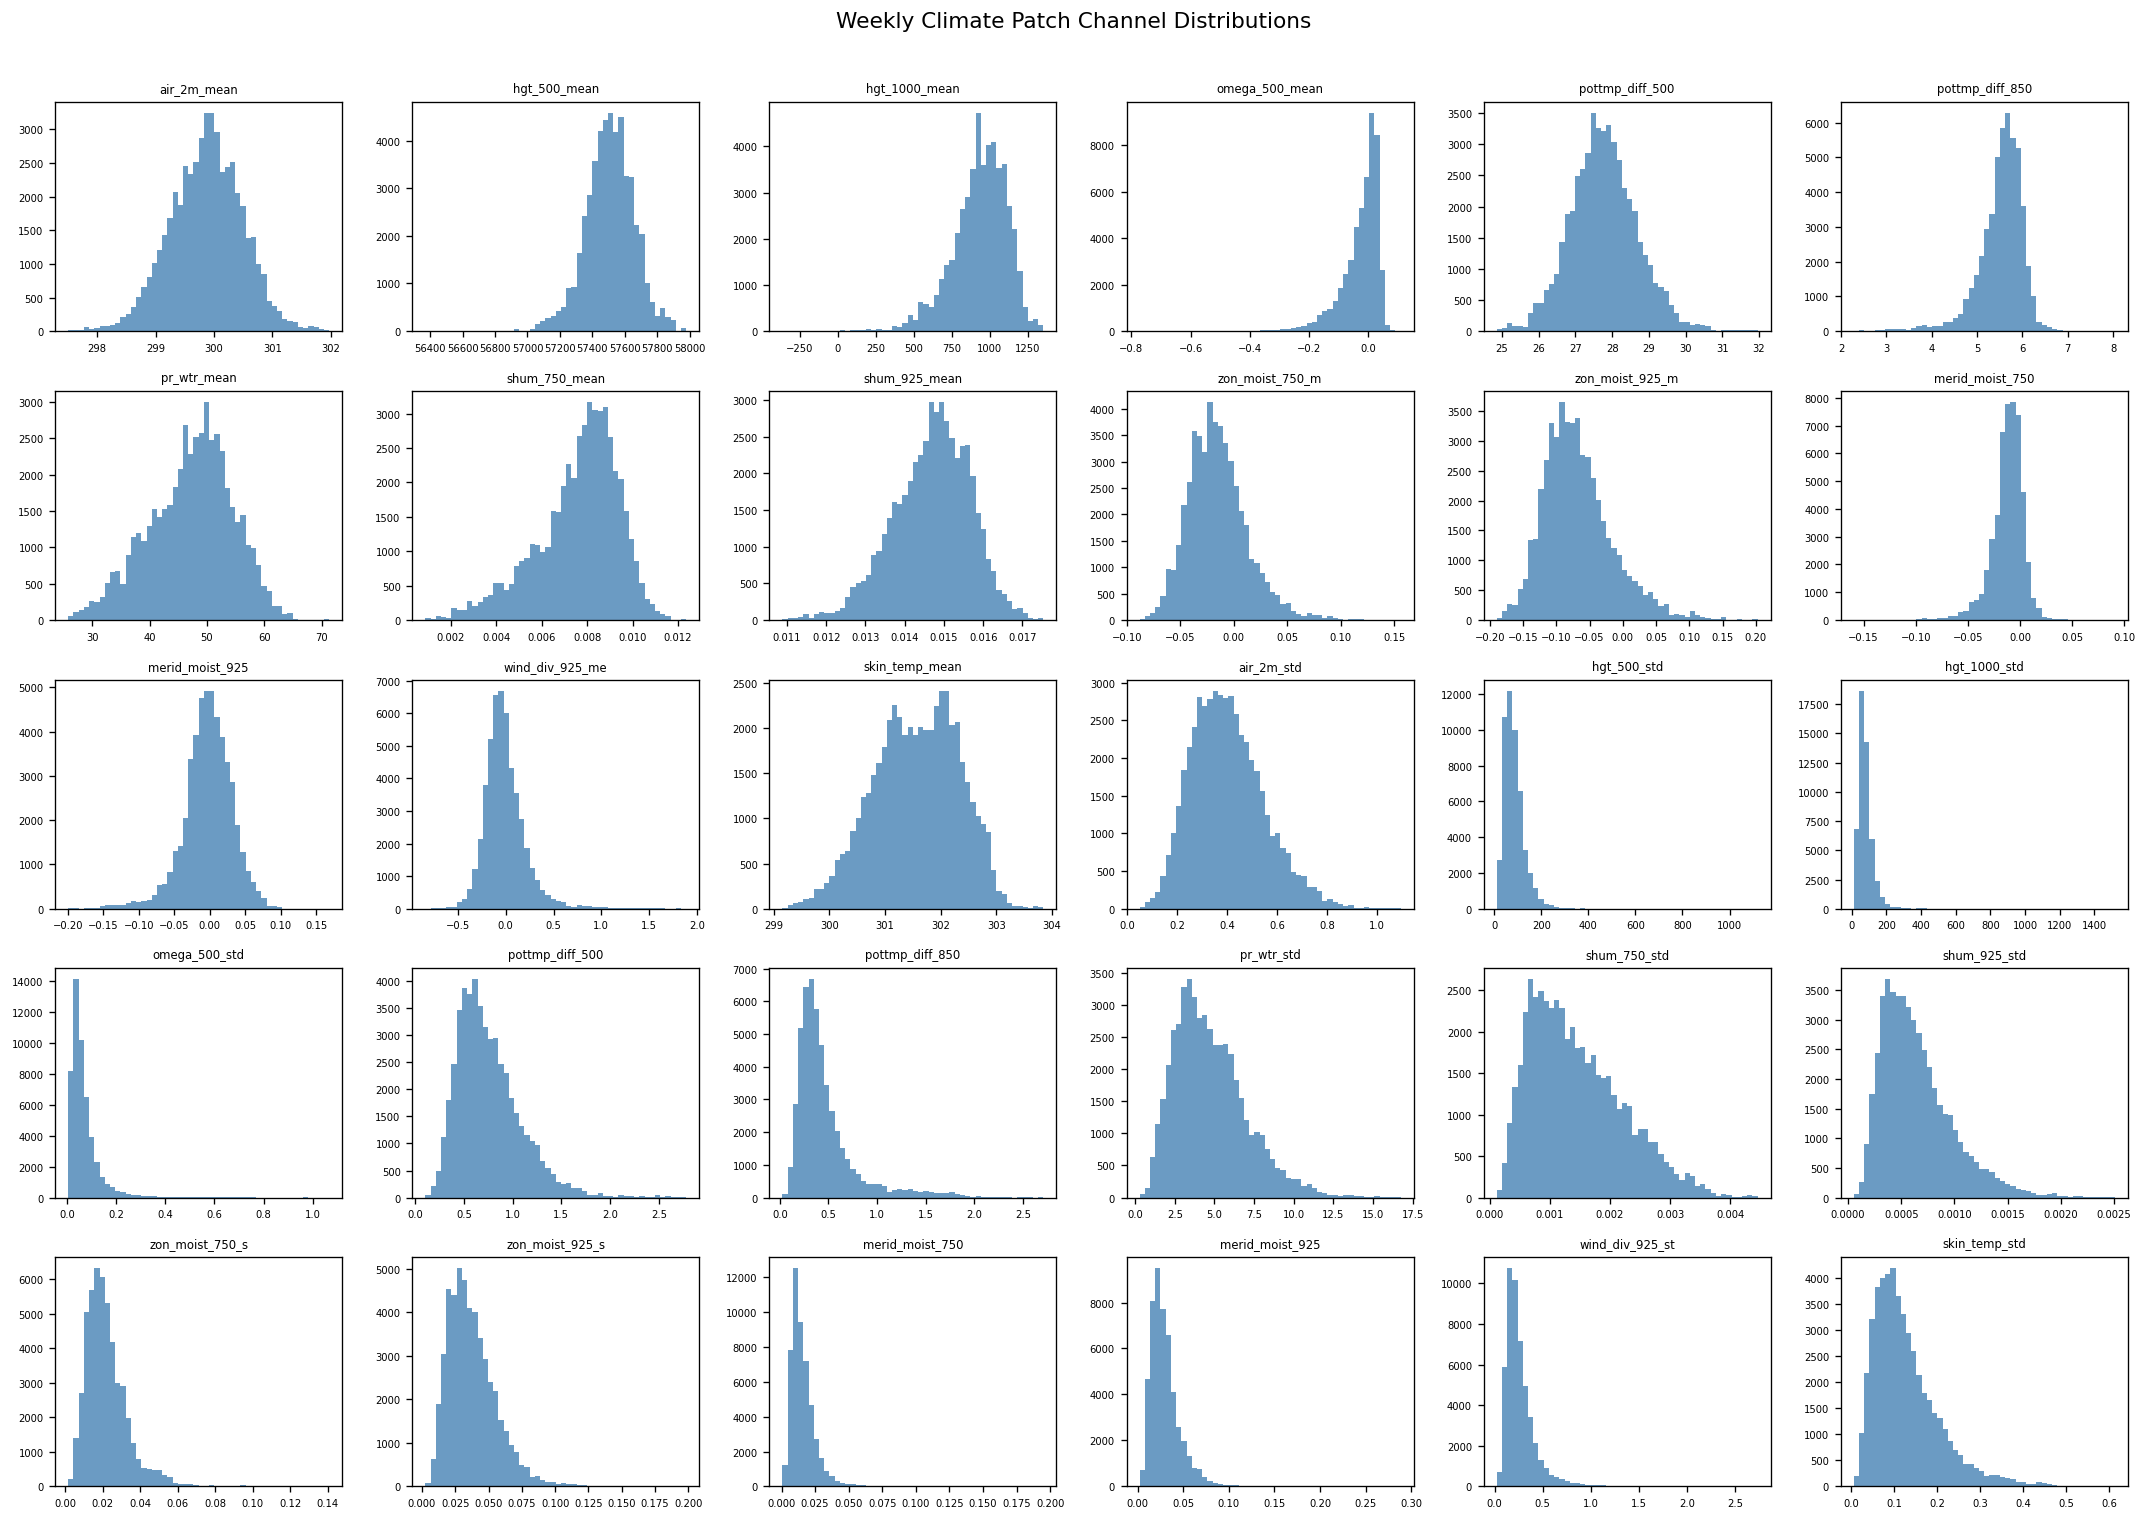

In [25]:
# Distribution of each weekly climate channel
n_show_ch = min(n_ch_week, 30)
ncols_ch = 6
nrows_ch = int(np.ceil(n_show_ch / ncols_ch))
fig, axes = plt.subplots(nrows_ch, ncols_ch, figsize=(3 * ncols_ch, 2.5 * nrows_ch))
axes = axes.ravel()

rng = np.random.default_rng(42)
for i in range(n_show_ch):
    vals = climate_patches[:, i, :, :].flatten()
    sample = rng.choice(vals, size=min(50000, len(vals)), replace=False)
    axes[i].hist(sample, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    label = str(ds_variables[i])[:15] if i < len(ds_variables) else f'ch_{i}'
    axes[i].set_title(label, fontsize=7)
    axes[i].tick_params(labelsize=6)
for j in range(n_show_ch, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Weekly Climate Patch Channel Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

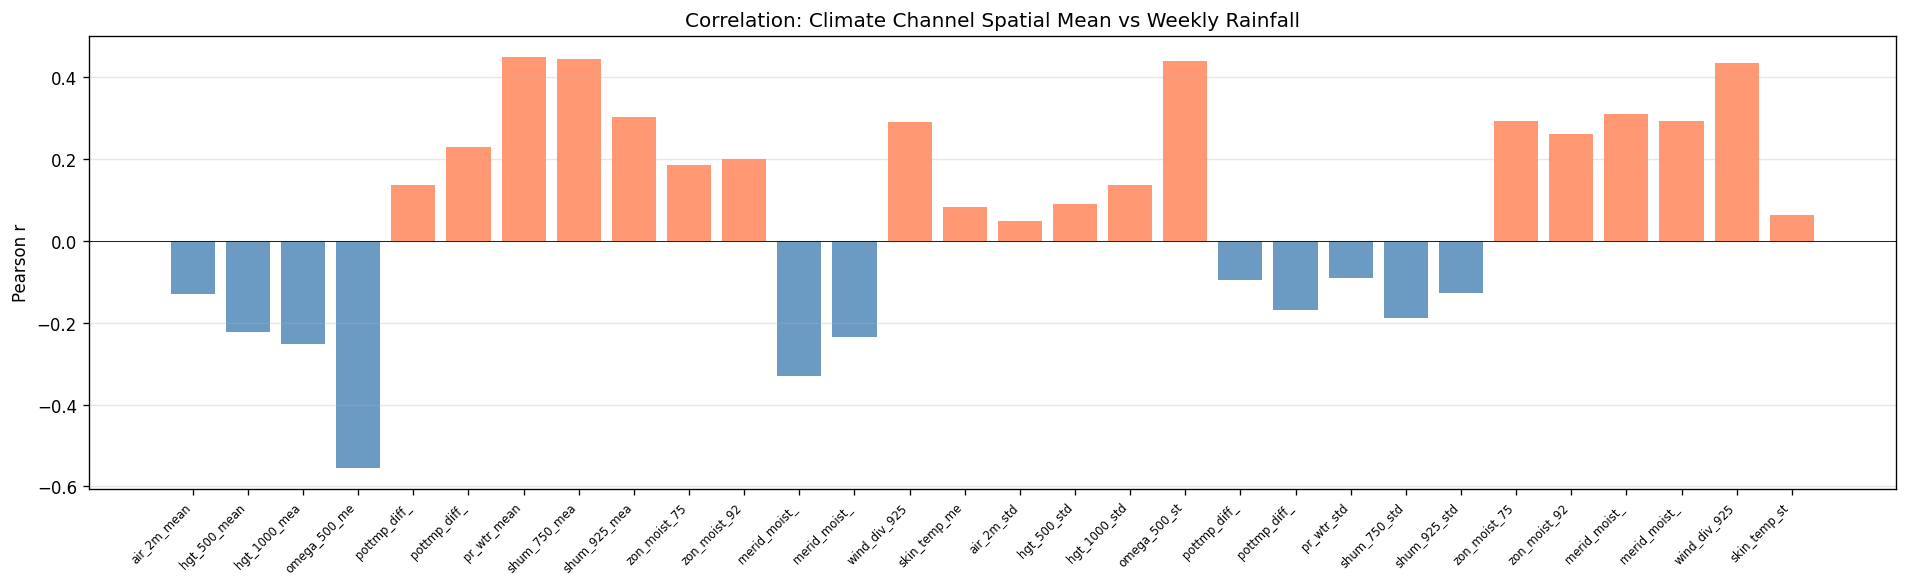

In [26]:
# Correlation between climate channel spatial means and rainfall
climate_means = np.nanmean(climate_patches, axis=(2, 3))  # (N, C)
correlations = []
for i in range(climate_means.shape[1]):
    valid = ~np.isnan(climate_means[:, i]) & ~np.isnan(rainfall)
    r = np.corrcoef(climate_means[valid, i], rainfall[valid])[0, 1]
    correlations.append(r)

fig, ax = plt.subplots(figsize=(16, 5))
colors_corr = ['coral' if c > 0 else 'steelblue' for c in correlations]
ax.bar(range(len(correlations)), correlations, color=colors_corr, alpha=0.8)
ax.set_xticks(range(len(correlations)))
ch_labels = [str(ds_variables[i])[:12] if i < len(ds_variables) else f'ch_{i}' for i in range(len(correlations))]
ax.set_xticklabels(ch_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Pearson r')
ax.set_title('Correlation: Climate Channel Spatial Mean vs Weekly Rainfall')
ax.axhline(0, color='black', lw=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

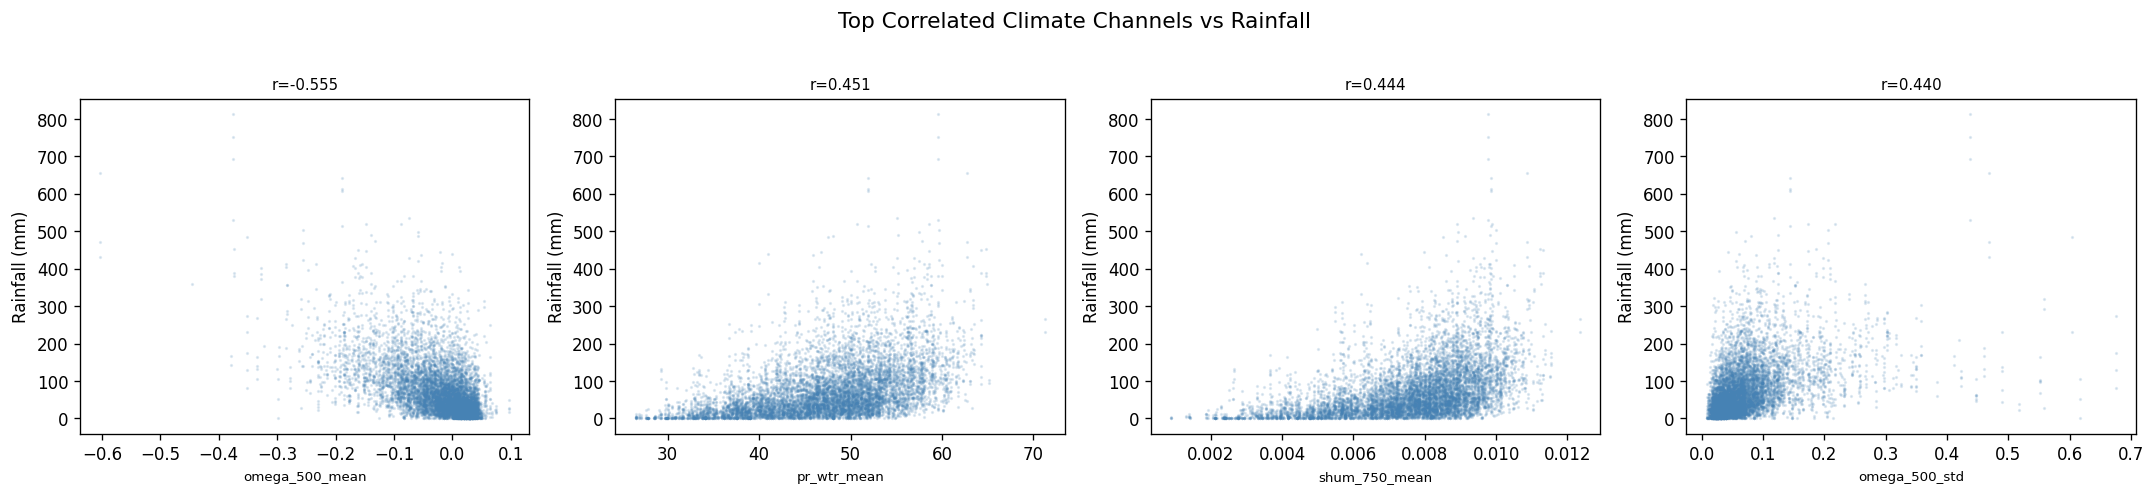

In [27]:
# Scatter of top-correlated climate channels vs rainfall
abs_corr = np.abs(correlations)
top_idx = np.argsort(abs_corr)[-4:][::-1]  # top 4

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, idx in zip(axes, top_idx):
    x = climate_means[:, idx]
    valid = ~np.isnan(x)
    ax.scatter(x[valid], rainfall[valid], s=1, alpha=0.15, color='steelblue')
    label = str(ds_variables[idx])[:15] if idx < len(ds_variables) else f'ch_{idx}'
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Rainfall (mm)')
    ax.set_title(f'r={correlations[idx]:.3f}', fontsize=9)
fig.suptitle('Top Correlated Climate Channels vs Rainfall', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Missing Data & Quality Checks

In [28]:
# NaN/missing analysis
print('=== Missing Data Summary ===')
print(f'Rainfall NaN count: {np.isnan(rainfall).sum()}')
print(f'Rainfall zeros: {(rainfall == 0).sum()} ({100*(rainfall == 0).mean():.1f}%)')
print(f'Climate NaN count: {np.isnan(climate_patches).sum()} out of {climate_patches.size}')

# NaN fraction per climate channel
nan_frac_per_ch = np.isnan(climate_patches).reshape(n_week, n_ch_week, -1).any(axis=2).mean(axis=0)
if nan_frac_per_ch.max() > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_ch_week), nan_frac_per_ch * 100, color='salmon')
    ax.set_xticks(range(n_ch_week))
    ax.set_xticklabels(ch_labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('% samples with NaN')
    ax.set_title('NaN Fraction per Climate Channel')
    plt.tight_layout()
    plt.show()
else:
    print('No NaN values in climate patches.')

=== Missing Data Summary ===
Rainfall NaN count: 0
Rainfall zeros: 216 (2.5%)
Climate NaN count: 0 out of 2324160
No NaN values in climate patches.


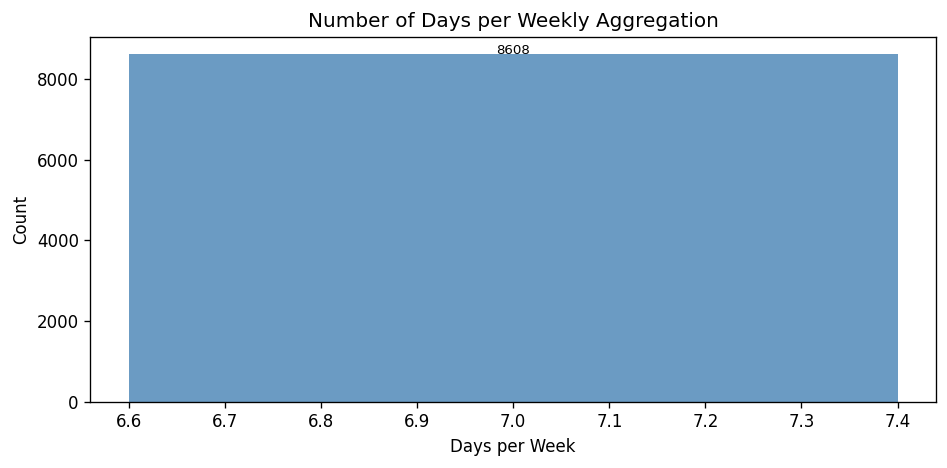

In [29]:
# n_days per week distribution (incomplete weeks?)
if 'n_days' in ds.keys():
    n_days = ds['n_days']
    fig, ax = plt.subplots(figsize=(8, 4))
    unique_ndays, counts_ndays = np.unique(n_days, return_counts=True)
    ax.bar(unique_ndays, counts_ndays, color='steelblue', alpha=0.8)
    ax.set_xlabel('Days per Week')
    ax.set_ylabel('Count')
    ax.set_title('Number of Days per Weekly Aggregation')
    for x, y in zip(unique_ndays, counts_ndays):
        ax.text(x, y + 10, f'{y}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('n_days not in dataset')

### 3.5 Extreme Rainfall Analysis

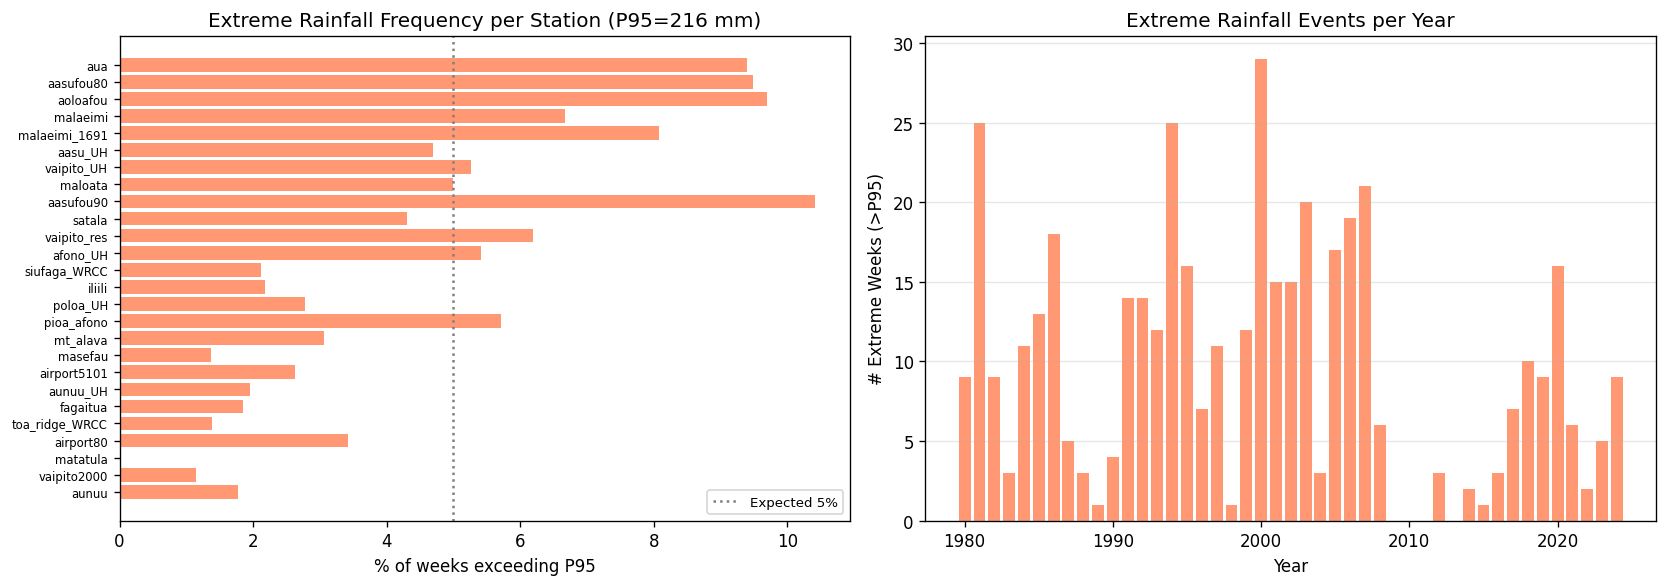

P95 threshold: 215.9 mm
P99 threshold: 334.2 mm
Max rainfall: 812.8 mm


In [30]:
# Extreme rainfall events (P95, P99)
p95 = np.percentile(rainfall, 95)
p99 = np.percentile(rainfall, 99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extreme events per station
extreme_counts = []
for s in station_order:
    mask = stations == s
    extreme_counts.append(np.sum(rainfall[mask] > p95) / mask.sum() * 100)

axes[0].barh(range(len(station_order)), extreme_counts, color='coral', alpha=0.8)
axes[0].set_yticks(range(len(station_order)))
axes[0].set_yticklabels(station_order, fontsize=7)
axes[0].axvline(5, color='gray', ls=':', label='Expected 5%')
axes[0].set_xlabel('% of weeks exceeding P95')
axes[0].set_title(f'Extreme Rainfall Frequency per Station (P95={p95:.0f} mm)')
axes[0].legend(fontsize=8)

# Extreme events per year
extreme_by_year = []
for y in unique_years:
    mask = years == y
    extreme_by_year.append(np.sum(rainfall[mask] > p95))

axes[1].bar(unique_years, extreme_by_year, color='coral', alpha=0.8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('# Extreme Weeks (>P95)')
axes[1].set_title('Extreme Rainfall Events per Year')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'P95 threshold: {p95:.1f} mm')
print(f'P99 threshold: {p99:.1f} mm')
print(f'Max rainfall: {rainfall.max():.1f} mm')

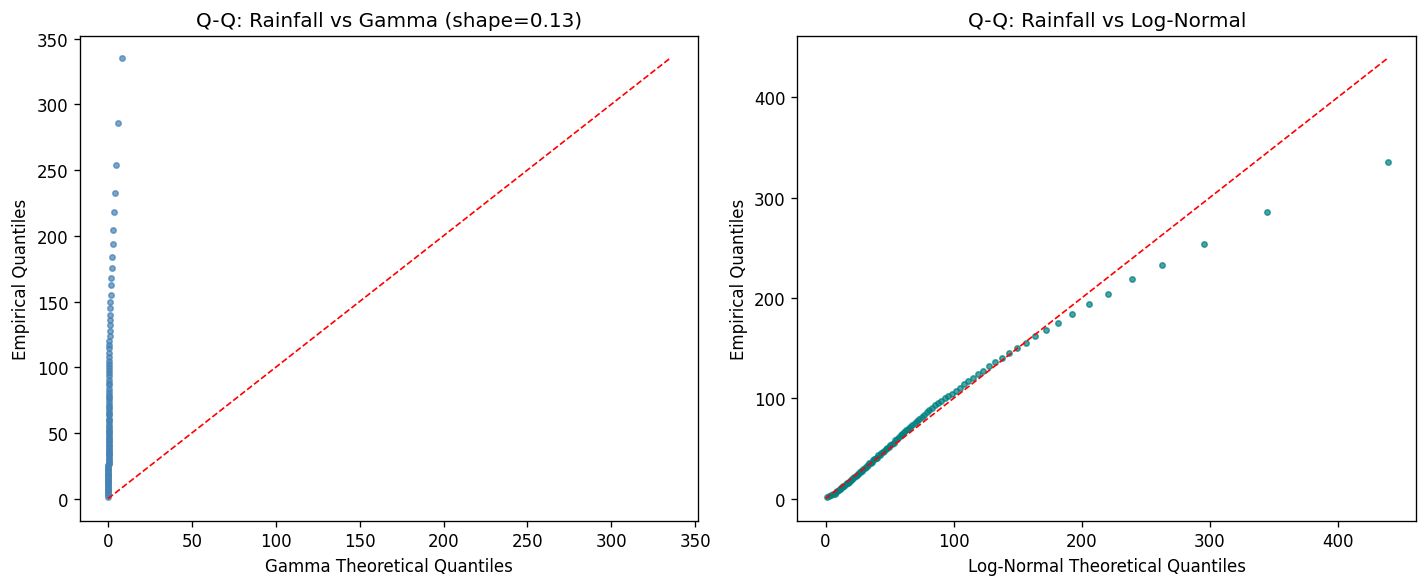

In [31]:
# Q-Q plot vs exponential/gamma reference
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q against gamma distribution
positive_rain = rainfall[rainfall > 0]
gamma_params = stats.gamma.fit(positive_rain)
theoretical_q = stats.gamma.ppf(np.linspace(0.01, 0.99, 100), *gamma_params)
empirical_q = np.percentile(positive_rain, np.linspace(1, 99, 100))

axes[0].scatter(theoretical_q, empirical_q, s=10, color='steelblue', alpha=0.7)
max_val = max(theoretical_q.max(), empirical_q.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1)
axes[0].set_xlabel('Gamma Theoretical Quantiles')
axes[0].set_ylabel('Empirical Quantiles')
axes[0].set_title(f'Q-Q: Rainfall vs Gamma (shape={gamma_params[0]:.2f})')

# Q-Q against log-normal
ln_params = stats.lognorm.fit(positive_rain)
theoretical_ln = stats.lognorm.ppf(np.linspace(0.01, 0.99, 100), *ln_params)

axes[1].scatter(theoretical_ln, empirical_q, s=10, color='teal', alpha=0.7)
max_val = max(theoretical_ln.max(), empirical_q.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=1)
axes[1].set_xlabel('Log-Normal Theoretical Quantiles')
axes[1].set_ylabel('Empirical Quantiles')
axes[1].set_title('Q-Q: Rainfall vs Log-Normal')

plt.tight_layout()
plt.show()

### 3.6 Station DEM Index Mapping

In [32]:
# Verify station DEM index mapping
print('Station DEM index mapping:')
unique_idx = np.unique(station_dem_idx)
for idx in unique_idx:
    mask = station_dem_idx == idx
    station_names = np.unique(stations[mask])
    dem_name = dem_stations[idx] if idx < len(dem_stations) else '??'
    print(f'  DEM[{idx}]={dem_name} -> stations: {list(station_names)}')

Station DEM index mapping:
  DEM[0]=aasu_UH -> stations: [np.str_('aasu_UH')]
  DEM[1]=aasufou80 -> stations: [np.str_('aasufou80')]
  DEM[2]=aasufou90 -> stations: [np.str_('aasufou90')]
  DEM[3]=afono_UH -> stations: [np.str_('afono_UH')]
  DEM[4]=airport5101 -> stations: [np.str_('airport5101')]
  DEM[5]=airport80 -> stations: [np.str_('airport80')]
  DEM[6]=aoloafou -> stations: [np.str_('aoloafou')]
  DEM[7]=aua -> stations: [np.str_('aua')]
  DEM[8]=aunuu -> stations: [np.str_('aunuu')]
  DEM[9]=aunuu_UH -> stations: [np.str_('aunuu_UH')]
  DEM[10]=fagaitua -> stations: [np.str_('fagaitua')]
  DEM[11]=iliili -> stations: [np.str_('iliili')]
  DEM[12]=malaeimi -> stations: [np.str_('malaeimi')]
  DEM[13]=malaeimi_1691 -> stations: [np.str_('malaeimi_1691')]
  DEM[14]=maloata -> stations: [np.str_('maloata')]
  DEM[15]=masefau -> stations: [np.str_('masefau')]
  DEM[16]=matatula -> stations: [np.str_('matatula')]
  DEM[17]=mt_alava -> stations: [np.str_('mt_alava')]
  DEM[18]=pioa_

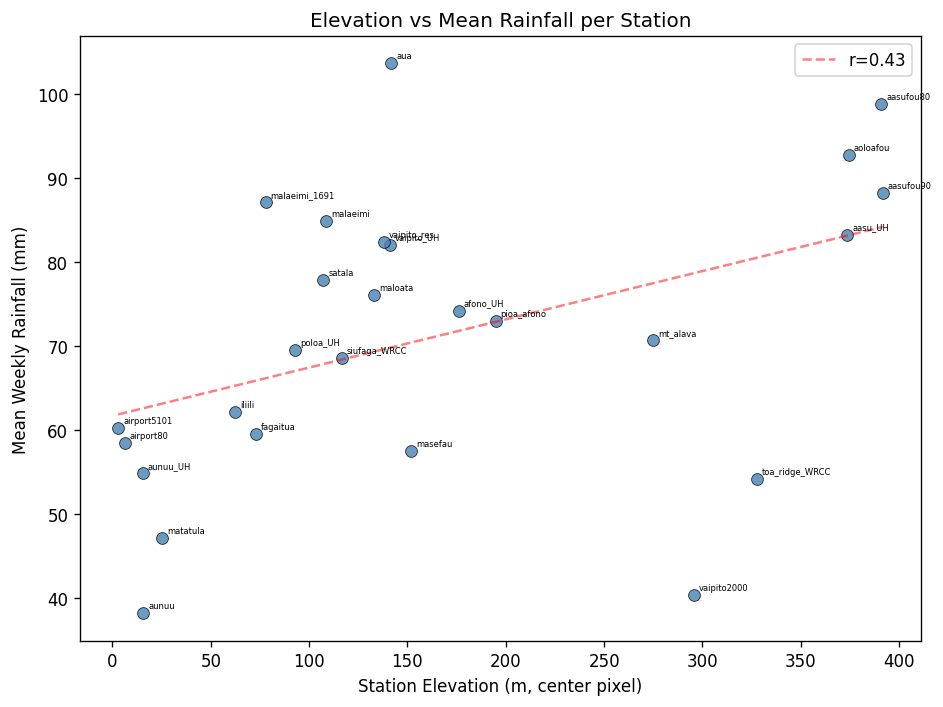

In [33]:
# Relationship between DEM elevation and mean rainfall per station
station_mean_rain = {}
station_mean_elev = {}
for s in unique_stations:
    mask = stations == s
    dem_idx = station_dem_idx[mask][0]
    elev_patch = dem['dem_local_raw'][dem_idx, 0]  # band 0 = elevation
    center_h, center_w = elev_patch.shape[0] // 2, elev_patch.shape[1] // 2
    station_mean_rain[s] = rainfall[mask].mean()
    # Use center pixel as station elevation estimate
    station_mean_elev[s] = float(elev_patch[center_h, center_w])

fig, ax = plt.subplots(figsize=(8, 6))
x_elev = list(station_mean_elev.values())
y_rain = list(station_mean_rain.values())
ax.scatter(x_elev, y_rain, s=50, color='steelblue', alpha=0.8, edgecolor='black', lw=0.5)
for s in unique_stations:
    ax.annotate(s, (station_mean_elev[s], station_mean_rain[s]), fontsize=5,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Station Elevation (m, center pixel)')
ax.set_ylabel('Mean Weekly Rainfall (mm)')
ax.set_title('Elevation vs Mean Rainfall per Station')

# Trend
valid = np.array(x_elev), np.array(y_rain)
z = np.polyfit(*valid, 1)
ax.plot(np.sort(valid[0]), np.polyval(z, np.sort(valid[0])), 'r--', alpha=0.5,
        label=f'r={np.corrcoef(*valid)[0,1]:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

### 3.7 Month One-Hot Verification

Month one-hot encoding is consistent with months array


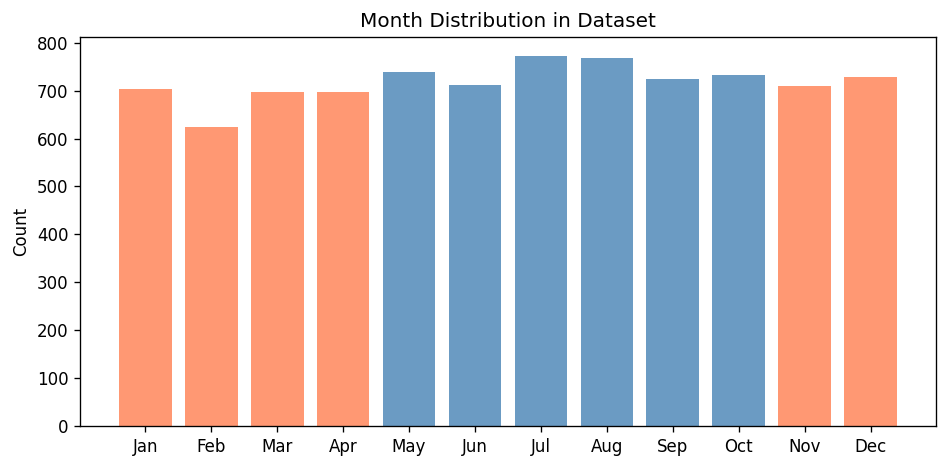

In [34]:
# Verify month one-hot encoding
decoded_months = np.argmax(month_onehot, axis=1) + 1  # 1-indexed
if np.array_equal(decoded_months, months):
    print('Month one-hot encoding is consistent with months array')
else:
    mismatches = np.sum(decoded_months != months)
    print(f'WARNING: {mismatches} mismatches between one-hot and months')

# Month distribution
fig, ax = plt.subplots(figsize=(8, 4))
month_dist = Counter(months)
ax.bar([month_names[m-1] for m in sorted(month_dist.keys())],
       [month_dist[m] for m in sorted(month_dist.keys())],
       color=colors_monthly, alpha=0.8)
ax.set_ylabel('Count')
ax.set_title('Month Distribution in Dataset')
plt.tight_layout()
plt.show()

---
## Summary

Key takeaways from the data preparation:
- Rainfall is heavily right-skewed (typical for tropical precipitation)
- Clear wet/dry seasonality (Nov-Apr vs May-Oct)
- Station coverage varies significantly over time
- DEM features capture local and regional topographic context
- Climate channels have diverse distributions; some are strongly correlated with rainfall